# PROJET DATA SCIENCE
# SUPPLY CHAIN - Satisfaction des clients

Pour de nombreux produits/ services, la satisfaction des clients se mesure sur les commentaires, avis de sites dédiés telles que : Trustpilot, twitter, facebook, site distributeurs etc.

Collecte de données : outil de scraping BeautifulSoup pour extraire les avis de plusieurs banques sur Trustpilot.

Nous avons décidé de nous orienter sur les entreprises de type Banque en Ligne pour identifier les thèmes dans les commentaires des clients de plusieurs banques afin d'obtenir des informations précieuses sur les perceptions des clients et les possibilités d'amélioration. Nous sauvegardons les données collectées dans un format CSV structuré avec des colonnes : Company Name, titre, ID, verif, rating avis Date, month, day & year. Les données ont été sauvegardées sur notre Drive partagé.

# OBJECTIF :

Déterminer les sujets de satisfaction et d'insatisfactions des entreprises du secteur, dans le but de proposer des points d'amélioration et d'etre dans la capacité de prédire les notes en fonction de l'avis laissé par client.


# 1) Webscrapping

Construction de jeu de données par webscrapping du site Trustpilot pour en extraire les avis de consommation.

In [ ]:
#imports
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
import time
#dossier_portable = "C:/Users/matth/Desktop/Dossier Formation/Projet Fil Rouge"
#dossier = "C:/Users/matth/OneDrive/Formation/Projet Fil Rouge"

In [ ]:
def scrape_trustpilot(company_name, num_pages):
    reviews = []
    base_url = f"https://fr.trustpilot.com/review/{company_name}"



    for page in range(1, num_pages + 1):
        url = f"{base_url}?page={page}"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        time.sleep(3)  # Attendre que la page se charge
        review_elements = soup.find_all("div", {"class": "styles_cardWrapper__LcCPA"})

        for review in review_elements:
            id_cust = review.find("span", {"class": "typography_heading-xxs__QKBS8 typography_appearance-default__AAY17"})
            verif= review.find("button", {"class": "styles_reviewLabelButton__SNIsL"})
            title_element = review.find("h2", {"class": "typography_heading-s__f7029"})
            rating_element_indiv = review.find("div", {"class": "styles_reviewHeader__iU9Px"})
            text_element = review.find("p", {"class": "typography_body-l__KUYFJ"})
            date_element = review.find("time")

            id_cust = id_cust.text.strip() if text_element else 'No Text'
            verif = verif.text.strip() if verif else 'Non vérifié'
            title = title_element.text.strip() if title_element else 'No Title'
            rating = rating_element_indiv['data-service-review-rating'] if rating_element_indiv and 'data-service-review-rating' in rating_element_indiv.attrs else 'No Rating'
            text = text_element.text.strip() if text_element else 'No Text'
            date = date_element['datetime'] if date_element else 'No Date'

            reviews.append({
                'company_name': company_name,  # Add company name
                'title': title,
                'id_cust': id_cust,
                'verif': verif,
                'rating_indiv': rating,
                'commentaire': text,
                'date': date
            })

    return pd.DataFrame(reviews)

In [ ]:
# Utilisation de la fonction pour chacune des entreprises, de façon séparée.
# Nous avons fait le choix de lancer des traitements pour optimiser les temps de traitementn (Erreurs, temps de traitement...)
#
df = scrape_trustpilot('bforbank.com',51)

#sauvegarde de fichier

df.to_csv(os.path.join(dossier, 'df_bforbank.csv'), index=False)

In [ ]:
# Union des Dataframes, nous regroupons les dataframe de chacune des compagnies pour n'en faire qu'un seul

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

dossier = "C:/Users/matth/OneDrive/Formation/Projet Fil Rouge"

%matplotlib

df1 = pd.read_csv('df_boursobank.csv')
df2 = pd.read_csv('df_bforbank.csv')
df3 = pd.read_csv('df_fortuneo.csv')
df4 = pd.read_csv('df_hellobank.csv')
df5 = pd.read_csv('df_n26.csv')
df6 = pd.read_csv('df_qonto.csv')
df7 = pd.read_csv('df_revolut.csv')
df8 = pd.read_csv('df_monabanq.csv')
df9 = pd.read_csv('df_orangebank.csv')
df10 = pd.read_csv('df_oney.csv')
df11 = pd.read_csv('df_nickel.csv')
df12 = pd.read_csv('df_mafrenchbanque.csv')
df13 = pd.read_csv('df_floabank.csv')
df14 = pd.read_csv('df_younitedcredit.csv')
df15 = pd.read_csv('df_cofidis.csv')

df = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10,df11,df12,df13,df14,df15])

df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df.Date.dt.month
df['day'] = df.Date.dt.day
df['year'] = df.Date.dt.year

df.to_csv(os.path.join(dossier, 'df_bank.csv'), index=False)

# 2) Nettoyage de données et pre-processing

In [ ]:
#Import du Drive dans goole colab (Local df = pd.read_csv(r"C:\Users\Maison\Downloads\df_bank.csv")
#drive.flush_and_unmount()
from google.colab import drive
drive.mount('/content/drive')

# import des librairies
import numpy as np
import pandas as pd

# lecture du dataframe
df = pd.read_csv("/content/drive/MyDrive/df_bank.csv")

Mounted at /content/drive


In [ ]:
# visualization des premières lignes du DataFrame
df.head()

,Company Name,titre,ID,verif,rating,avis,Date,month,day,year
0,boursobank.com,Carte piratée,GILLES DERELLE,Sur invitation,5,Je suis en vacances en Indonésie. Avis d'utili...,2024-10-09,10,9,2024
1,boursobank.com,Application bancaire fluide,Cyril P.,Sur invitation,5,"Application bancaire fluide, rapide, ergonomiq...",2024-10-09,10,9,2024
2,boursobank.com,Parfait !,Bad Wolf,Non vérifié,5,Je ne peux que recommander BoursoBank. Bien qu...,2024-10-08,10,8,2024
3,boursobank.com,Connexion impossible,Jean-Paul Cauchin,Sur invitation,4,La connexion sur l'application mobile est parf...,2024-10-07,10,7,2024
4,boursobank.com,Je suis assez satisfaite des services…,Sophie R,Sur invitation,5,Je suis assez satisfaite des services de Bours...,2024-10-08,10,8,2024


In [ ]:
# Nous avons récuperé un Dataframe avec de 10 Colonnes et 188 759 lignes
df.shape

(188759, 10)

In [ ]:
# Nous vérifions la cohérence de types des variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188759 entries, 0 to 188758
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Company Name  188759 non-null  object
 1   titre         188759 non-null  object
 2   ID            188754 non-null  object
 3   verif         188759 non-null  object
 4   rating        188759 non-null  int64 
 5   avis          188759 non-null  object
 6   Date          188759 non-null  object
 7   month         188759 non-null  int64 
 8   day           188759 non-null  int64 
 9   year          188759 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 14.4+ MB


In [ ]:
# Nous affichons les variables avec les indicateurs statistiques grâce au describe
df.describe()

,rating,month,day,year
count,188759.000000,188759.000000,188759.000000,188759.000000
mean,4.310353,6.280093,15.978735,2021.547465
std,1.312964,3.306446,8.747031,2.079039
min,1.000000,1.000000,1.000000,2012.000000
25%,4.000000,4.000000,8.000000,2020.000000
50%,5.000000,6.000000,17.000000,2022.000000
75%,5.000000,9.000000,23.000000,2023.000000
max,5.000000,12.000000,31.000000,2024.000000


In [ ]:
#Nous vérifions si la dataframe contient des doublons?
df.duplicated().sum()

312

In [ ]:
#Nous comptabilisons les doublons en fonction des trois colonnes [ID', 'avis', 'titre'] (doublons de commentaires()
df.duplicated(subset=['ID', 'avis', 'titre']).sum()

9433

In [ ]:
#Nous gardons les données de doublon dans un dataframe df1
df2 = [df[df.duplicated(subset=['ID', 'avis', 'titre'])]]

In [ ]:
#Nous visualisons les 5 premières lignes du DF des informations en doublons
display(df2[0:5])

[          Company Name                  titre       ID           verif  \
 204     boursobank.com     Simple et efficace  No Text  Sur invitation   
 339     boursobank.com       Simple et rapide  No Text  Sur invitation   
 381     boursobank.com     Simple et efficace  No Text  Sur invitation   
 422     boursobank.com       Facile et rapide  No Text  Sur invitation   
 441     boursobank.com       Facile et rapide  No Text  Sur invitation   
 ...                ...                    ...      ...             ...   
 188518      cofidis.fr     rapide et efficace  No Text  Sur invitation   
 188523      cofidis.fr       Simple et rapide  No Text  Sur invitation   
 188531      cofidis.fr        Efficace rapide  No Text  Sur invitation   
 188595      cofidis.fr  Très rapide et facile  No Text  Sur invitation   
 188605      cofidis.fr     Efficace et rapide  No Text  Sur invitation   
 
         rating     avis        Date  month  day  year  
 204          5  No Text  2024-10-06     

In [ ]:
#Nous supprimons les doublons du dataframe de travail
df1 = df.drop_duplicates(subset=['ID', 'avis', 'titre'])

In [ ]:
#Et vérifions si les doublons sont supprimés
df1.duplicated().sum()

0

In [ ]:
#J'affiche la taille du nouveau dataframe avec 179326 lignes
df1.shape

(179326, 10)

In [ ]:
# Nous remarquons qu'a présent l'index est encore sur l'ancien jeu de données, nous devons à présent faire le reinitialiser l'index après la suppréssion des doublons
df1.reset_index(drop = True)

,Company Name,titre,ID,verif,rating,avis,Date,month,day,year
0,boursobank.com,Carte piratée,GILLES DERELLE,Sur invitation,5,Je suis en vacances en Indonésie. Avis d'utili...,2024-10-09,10,9,2024
1,boursobank.com,Application bancaire fluide,Cyril P.,Sur invitation,5,"Application bancaire fluide, rapide, ergonomiq...",2024-10-09,10,9,2024
2,boursobank.com,Parfait !,Bad Wolf,Non vérifié,5,Je ne peux que recommander BoursoBank. Bien qu...,2024-10-08,10,8,2024
3,boursobank.com,Connexion impossible,Jean-Paul Cauchin,Sur invitation,4,La connexion sur l'application mobile est parf...,2024-10-07,10,7,2024
4,boursobank.com,Je suis assez satisfaite des services…,Sophie R,Sur invitation,5,Je suis assez satisfaite des services de Bours...,2024-10-08,10,8,2024
...,...,...,...,...,...,...,...,...,...,...
179321,cofidis.fr,dés que vous tentez d'effectuez des…,saft,Non vérifié,1,COFIDIS FRAUDEUR!!!!dés que vous tentez d'effe...,2018-06-06,6,6,2018
179322,cofidis.fr,Ils vous harcèlent par mail ou courrier…,Zammit,Non vérifié,1,Ils vous harcèlent par mail ou courrier et qua...,2018-02-14,2,14,2018
179323,cofidis.fr,Cofidis + Amazon ça marche plutôt bien.,Joel,Non vérifié,4,En générale je poste des avis quand je ne suis...,2018-05-02,5,2,2018
179324,cofidis.fr,une perte de temps pour une offre exorbitante ...,Suzanne Rozec,Non vérifié,1,J'ai voulu faire un regroupement de crédits av...,2017-01-25,1,25,2017


In [ ]:
#Nous vérifion la présence des valeurs manquantes
df1.isna().sum()

,0
Company Name,0
titre,0
ID,5
verif,0
rating,0
avis,0
Date,0
month,0
day,0
year,0


In [ ]:
#Nous remplaçons les valeurs manquantes de client ID par 'unknown'
df1 = df1.fillna('Unknown')

In [ ]:
#Nous vérifions que nos modifications sont effectives
df1.isna().sum()

,0
Company Name,0
titre,0
ID,0
verif,0
rating,0
avis,0
Date,0
month,0
day,0
year,0


In [ ]:

#Nous avons dans un premier temps créé manuellement cette colonne, mais cette méthode contient des biais qui influence les ordres d'importances pour notre résultat à cause de la méthode map(nous devons créer notre colonne différement)
# A reVoir pour les labels des entreprises( faire attention à un ordre suggéré)+ la colonne verif
df1['company'] = df["Company Name"].map({
    'www.younited-credit.com':'Younited-Credit',
    'cofidis.fr':'Cofidis',
    'boursobank.com':'Boursorama',
    'nickel.eu':'Nickel',
    'orangebank.fr':'OrangeBank',
    'qonto.com':'Qonto',
    'floabank.fr':'FloaBank',
    'n26.com':'N26',
    'fortuneo.fr':'Fortuneo',
    'www.revolut.com':'Revolut',
    'www.monabanq.com':'Monabanq',
    'oney.fr':'Oney',
    'hellobank.fr':'Hellobank',
    'www.mafrenchbank.fr':'MaFrenchBank',
    'bforbank.com':'BforBank'
})
df1.head()
df1 = df1.drop(columns=['Company Name'])

In [ ]:
# verification que les transformations sont effectifs dans le dataframe df1

df1["company"].unique()

array(['Boursorama', 'BforBank', 'Fortuneo', 'Hellobank', 'N26', 'Qonto',
       'Revolut', 'Monabanq', 'OrangeBank', 'Oney', 'Nickel',
       'MaFrenchBank', 'FloaBank', 'Younited-Credit', 'Cofidis'],
      dtype=object)

In [ ]:
# Nous transformons le format de la date qui est en objet (du df.info() en amont) en format datetime pour améliorer la qualité des données et les traitements futurs
df1['Date'] = pd.to_datetime(df1['Date'])

In [ ]:
# Nous vérifions si le changement du format de date est effectif
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179326 entries, 0 to 188758
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   titre    179326 non-null  object        
 1   ID       179326 non-null  object        
 2   verif    179326 non-null  object        
 3   rating   179326 non-null  int64         
 4   avis     179326 non-null  object        
 5   Date     179326 non-null  datetime64[ns]
 6   month    179326 non-null  int64         
 7   day      179326 non-null  int64         
 8   year     179326 non-null  int64         
 9   company  179326 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 15.0+ MB


Après le travail sur les dates et la qualité des variables, nous nous penchons sur les variables de texte. Nous avons fait le choix de les regrouper "titre" et "avis" en un seul corpus. Ceci pour mieux analyser les mots et faire emerger les catégories, les sujets les plus representatifs laissés par les clients.

In [ ]:
# Fonction pour fusionner deux variables (Text+titre)
def merge_tokens(avis, titre):
    return avis + titre

# Application de la fusion des colonnes
df1['avis_global'] = df1.apply(lambda row: merge_tokens(row['titre'] +' ', row['avis']), axis=1)

print(df1[['avis_global']])
#Ce code crée une nouvelle colonne avis global qui contient les colonnes fusionnés et nous n'avons donc plus besoin de "titre" et "avis"
df1 = df1.drop(columns=['titre','avis'])

                                              avis_global
0       Carte piratée Je suis en vacances en Indonésie...
1       Application bancaire fluide Application bancai...
2       Parfait ! Je ne peux que recommander BoursoBan...
3       Connexion impossible La connexion sur l'applic...
4       Je suis assez satisfaite des services… Je suis...
...                                                   ...
188754  dés que vous tentez d'effectuez des… COFIDIS F...
188755  Ils vous harcèlent par mail ou courrier… Ils v...
188756  Cofidis + Amazon ça marche plutôt bien. En gén...
188757  une perte de temps pour une offre exorbitante ...
188758  Prélèvement abusif J'ai fait appel à Cofidis p...

[179326 rows x 1 columns]


In [ ]:
df1.head()

,ID,verif,rating,Date,month,day,year,company,avis_global
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...
2,Bad Wolf,Non vérifié,5,2024-10-08,10,8,2024,Boursorama,Parfait ! Je ne peux que recommander BoursoBan...
3,Jean-Paul Cauchin,Sur invitation,4,2024-10-07,10,7,2024,Boursorama,Connexion impossible La connexion sur l'applic...
4,Sophie R,Sur invitation,5,2024-10-08,10,8,2024,Boursorama,Je suis assez satisfaite des services… Je suis...


 **Intégration des variables complémentaires liées aux caractéristiques des avis clients**

Nous allons utiliser ici des variables liées aux modelisations des sentiments pour créer des variables qui pourront peut être nous donner des informations complementaires.

In [ ]:
import re

# Nous allons utiliser ces fonctions pour créer des variables qui vont nous permettre de décomposer notre compréhension du sujet

def findLink(texte):
    r1 = re.compile(r"https?://[a-zA-Z0-9./]+")
    links = r1.findall(texte)
    r2 = re.compile(r"www\.[a-zA-Z0-9.-:/]+")
    links += r2.findall(texte)
    return len(links)

def findMail(texte):
    r = re.compile(r"[a-zA-Z0-9.-]+@[a-zA-Z.]+")
    mails = r.findall(texte)
    return len(mails)


def findQuote(texte):
    r = re.compile(r"@[a-zA-Z0-9]+")
    quote = r.findall(texte)
    return len(quote)

def findHashtag(texte):
    r = re.compile(r"#[a-zA-Z0-9]+")
    hashtag = r.findall(texte)
    return len(hashtag)

def findCAPSLOCK(texte):
    r = re.compile(r"[A-Z]")
    capslock = r.findall(texte)
    return len(capslock)

def find_chain_CAPSLOCK(texte):
    r = re.compile(r"[A-Z]{2,}")
    capslock = r.findall(texte)
    return len(capslock)

def find_exclamation(texte):
    r = re.compile(r"\!")
    exclamation = r.findall(texte)
    return len(exclamation)

def find_chain_exclamation(texte):
    r = re.compile(r"\!{2,}")
    exclamation = r.findall(texte)
    return len(exclamation)

def find_interogation(texte):
    r = re.compile(r"\?")
    interogation = r.findall(texte)
    return len(interogation)

def find_etc(texte):
    r = re.compile(r"\.{2,}")
    etc = r.findall(texte)
    return len(etc)

#j'applique les fonctions a mon text
# Quotes
df1['quotes'] = df1.avis_global.apply(lambda x: findQuote(x))

# Hastags
df1['hashtags'] = df1.avis_global.apply(lambda x: findHashtag(x))

# Others
df1['capslock'] = df1.avis_global.apply(lambda x: findCAPSLOCK(x))
df1['chain_capslock'] = df1.avis_global.apply(lambda x: find_chain_CAPSLOCK(x))
df1['exclamation'] = df1.avis_global.apply(lambda x: find_exclamation(x))
df1['chain_exclamation'] = df1.avis_global.apply(lambda x: find_chain_exclamation(x))
df1['interogation'] = df1.avis_global.apply(lambda x: find_interogation(x))
df1['etc'] = df1.avis_global.apply(lambda x: find_etc(x))
df1['message_len'] = df1.avis_global.apply(len)


In [ ]:
df1.head()

,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,hashtags,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,0,9,1,0,0,0,0,300
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,0,9,1,0,0,0,0,348
2,Bad Wolf,Non vérifié,5,2024-10-08,10,8,2024,Boursorama,Parfait ! Je ne peux que recommander BoursoBan...,0,0,10,0,1,0,0,0,466
3,Jean-Paul Cauchin,Sur invitation,4,2024-10-07,10,7,2024,Boursorama,Connexion impossible La connexion sur l'applic...,0,0,6,0,0,0,0,1,387
4,Sophie R,Sur invitation,5,2024-10-08,10,8,2024,Boursorama,Je suis assez satisfaite des services… Je suis...,0,0,5,0,0,0,0,0,243


Pour faire le travail de modelisation il nous sera surrement utile d'encoder les compagnies.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to the 'company' column and transform it
df1['company_encoded'] = label_encoder.fit_transform(df1['company'])

In [ ]:
df1.head(2)

,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,hashtags,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,0,9,1,0,0,0,0,300,1
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,0,9,1,0,0,0,0,348,1


In [ ]:
df1.to_csv('/content/drive/MyDrive/df_global.csv', index=False)


# 3) Exploratory Data Analysis (EDA)



Une fois le travail fait sur les dates et les variables nous explorons les données en fonction de la date.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# lecture du dataframe
df = pd.read_csv("/content/drive/MyDrive/df_global.csv")

df.head()

Mounted at /content/drive


,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,hashtags,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,0,9,1,0,0,0,0,300,1
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,0,9,1,0,0,0,0,348,1
2,Bad Wolf,Non vérifié,5,2024-10-08,10,8,2024,Boursorama,Parfait ! Je ne peux que recommander BoursoBan...,0,0,10,0,1,0,0,0,466,1
3,Jean-Paul Cauchin,Sur invitation,4,2024-10-07,10,7,2024,Boursorama,Connexion impossible La connexion sur l'applic...,0,0,6,0,0,0,0,1,387,1
4,Sophie R,Sur invitation,5,2024-10-08,10,8,2024,Boursorama,Je suis assez satisfaite des services… Je suis...,0,0,5,0,0,0,0,0,243,1


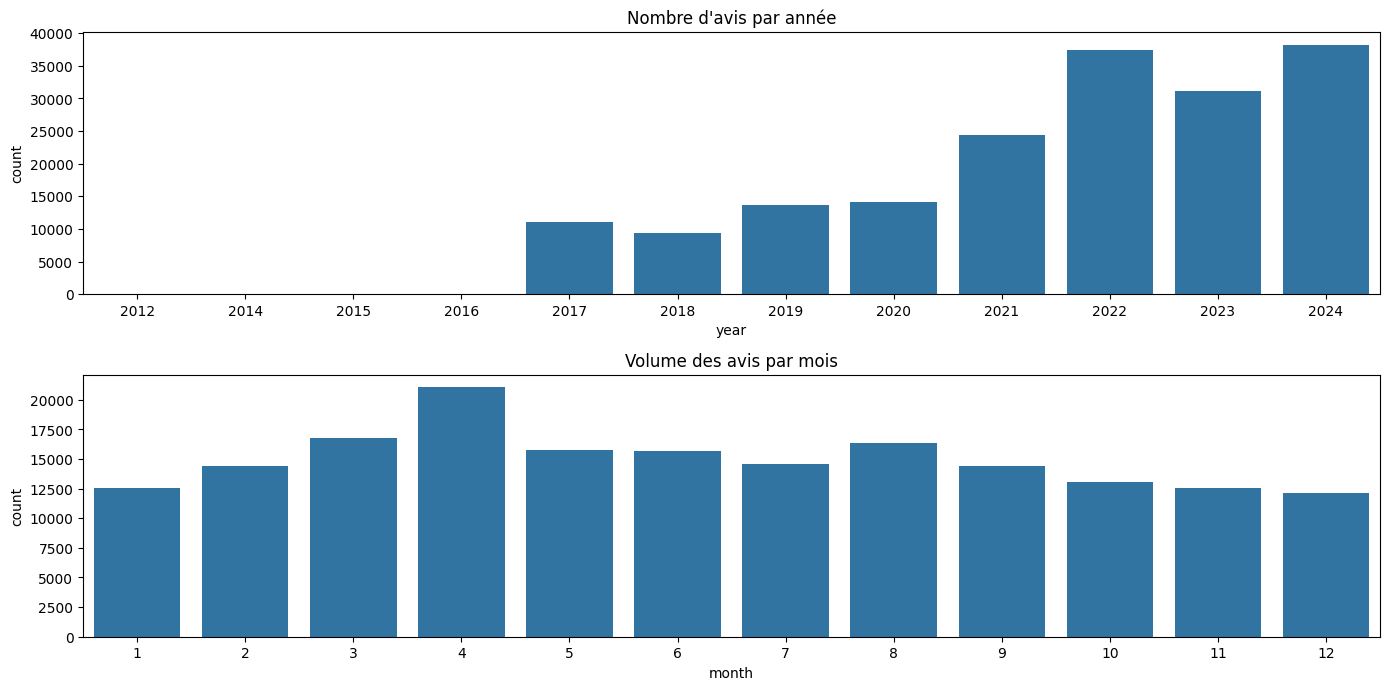

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# Subplot pour le nombre d'avis par année
plt.subplot(311)
sns.countplot(x="year", data=df1)
plt.title("Nombre d'avis par année")

# Subplot pour le nombre d'avis par mois
plt.subplot(312)
sns.countplot(x="month", data=df1)
plt.title("Volume des avis par mois")

plt.tight_layout()  # Ajuster la mise en page pour éviter le chevauchement
plt.show()

Nous constatons qu'il n'y a pas eu de commentaires avant l'année 2016.

Le premier graphique montre une augmentation du volume d'avis chaque année à partir de 2016. Les années 2022 et 2024 sont celles où le nombre d'avis enregistré est le plus élevé.
En 2023, nous remarquons une baisse significative du nombre d'avis (vs 2022). Cette baisse peut être expliquée par le retour à la normalité Post-Covid (retour des clients en banques traditionelles). De plus, en 2023, TrustPilot a changé d'algorythme et de politique de modération. Plusieurs avis ont donc été supprimés par le site.



Le deuxième graphique, qui montre la répartition mensuelle des avis, montre qu'environ 150 000 avis sont déposés en moyenne chaque mois, à l'exception du mois d'avril, qui est la meilleure période en termes de nombre d'avis déposés.
Ceci peut être expliqué par la publicité intensifiée durant ce mois, par les banques en général, après la révision des tarifs et taux bancaires.





Après visualisation des dates il nous parait important d'explorer la distribution des notes dans notre jeu de données

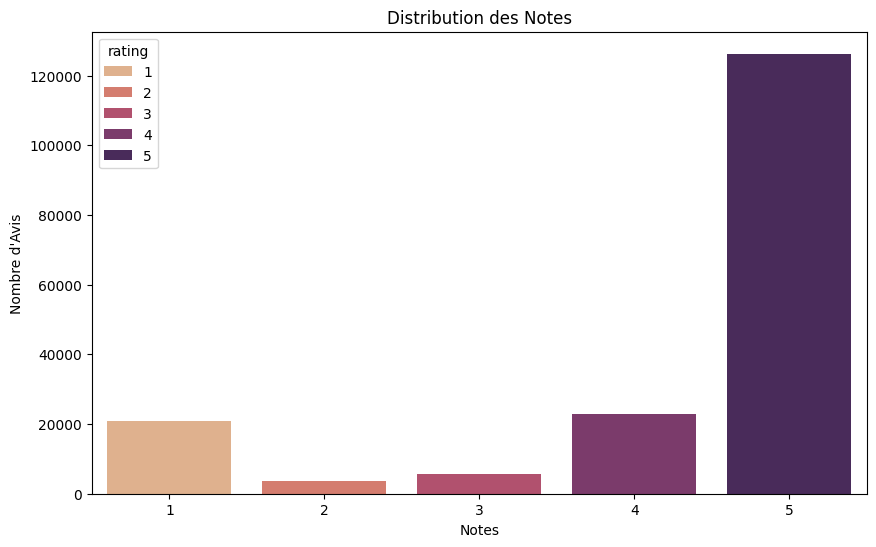

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df1, palette='flare',hue='rating')
plt.title('Distribution des Notes')
plt.xlabel('Notes')
plt.ylabel('Nombre d\'Avis')
plt.show()

Il convient de noter que la note 5 est de loin la plus courante dans notre jeu de données.

Nous pourrions penser que la distribution entre les notes 1 et 5 serait égale, ou que la note 1 serait prédominante, mais ce n'est pas le cas.

Nous aimerions approfondir la question et voir s'il existe des différences entre les entreprises en ce qui concerne ces notations.

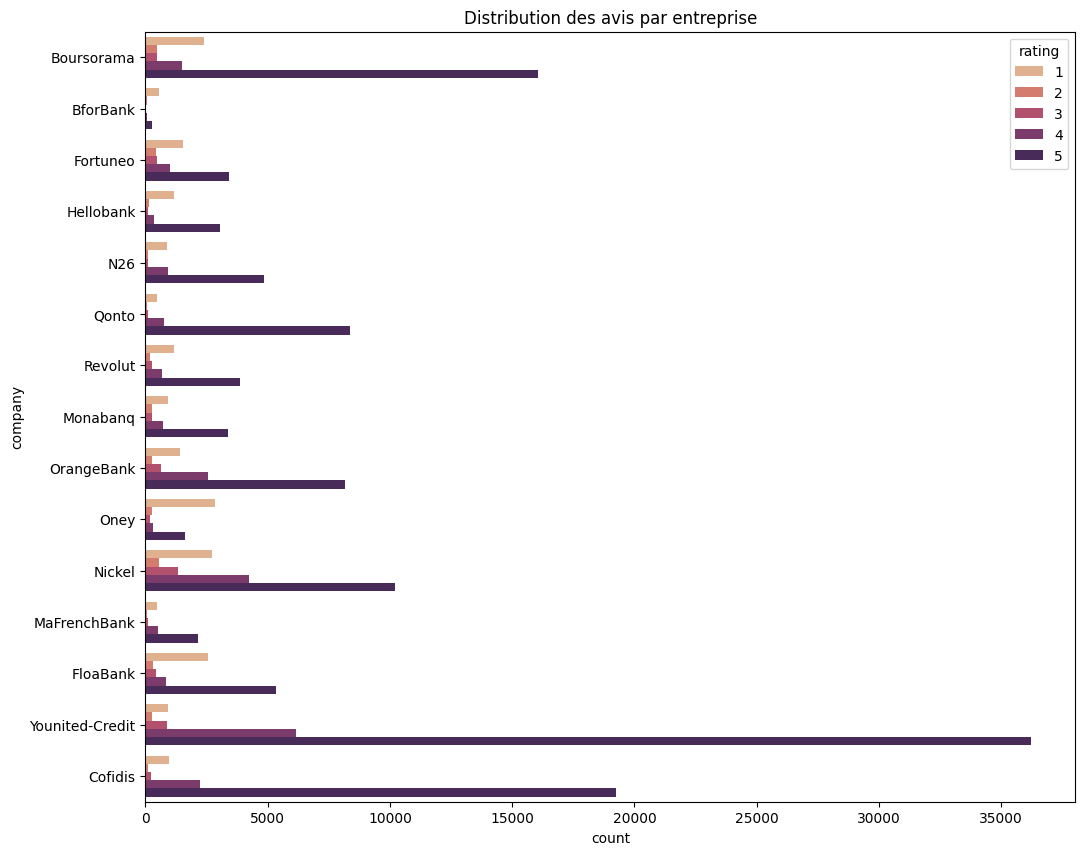

In [ ]:
plt.figure(figsize=(12, 10))
plt.subplot(111)
sns.countplot(y="company", hue='rating', palette='flare', data=df1)
plt.title("Distribution des avis par entreprise")
plt.show()

Le graphique confirme que 5 est la note la plus fréquente dans la plupart des entreprises. Cependant, nous constatons que certaines entreprises ont plus d'évaluations négatives (1) que d'autres. Nous aimerions donc analyser la proportion d'évaluations par entreprise afin de pouvoir les comparer.

In [ ]:
# le nombre d'avis par note et par entreprise
avis_par_entreprise = pd.crosstab(df1['company'], df1['rating'])
print(avis_par_entreprise)

rating              1    2     3     4      5
company                                      
BforBank          557   52    30    84    277
Boursorama       2391  462   469  1510  16048
Cofidis           976  111   224  2218  19261
FloaBank         2553  326   438   825   5357
Fortuneo         1553  420   457   990   3433
Hellobank        1156  141   113   354   3061
MaFrenchBank      458   77   111   511   2158
Monabanq          915  261   251   723   3385
N26               874  103   126   936   4841
Nickel           2709  539  1353  4241  10207
Oney             2850  272   185   306   1614
OrangeBank       1407  285   641  2545   8166
Qonto             480   75   101   759   8366
Revolut          1168  191   252   668   3868
Younited-Credit   926  287   893  6174  36221


In [ ]:
# Grouper par entreprise et note, puis compter
avis_par_ent_et_note = df1.groupby(['company', 'rating'])['rating'].count().reset_index(name='count')

# Calculer le total des avis par entreprise
total_avis_par_ent = avis_par_ent_et_note.groupby('company')['count'].sum().reset_index(name='total_count')

# Fusionner les deux DataFrames pour avoir le total des avis par mois dans le premier DataFrame
avis_par_ent_et_note = pd.merge(avis_par_ent_et_note, total_avis_par_ent, on='company')

# Calculer le pourcentage de la note 5
avis_par_ent_et_note['percentage'] = (avis_par_ent_et_note['count'] / avis_par_ent_et_note['total_count']) * 100

Graphique empilé en BAR des pourcentages et nombre d'avis

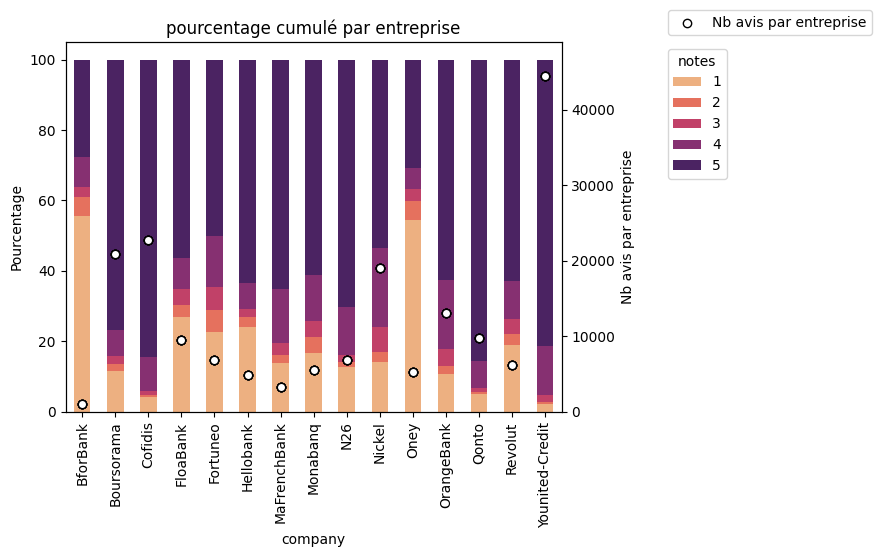

In [ ]:

# création du data frame pour le graphique
data_scatter = avis_par_ent_et_note[['company', 'rating', 'percentage','total_count']].reset_index(drop = True)

# Préparation des données pour le graphique empilé
pivot_table = data_scatter.pivot_table(values='percentage', index='company', columns='rating', aggfunc='sum').fillna(0)

# une palette de couleurs dégradée du bleu au orange et l'inverser
#colors = plt.cm.coolwarm(np.linspace(0, 1, 5))[::-1]

# Tracer le graphique empilé
ax = pivot_table.plot(kind='bar', stacked=True, cmap='flare')

# Tracer les points représentant les valeurs totales sur le graphique existant
ax2 = ax.twinx()  # Créer un deuxième axe y
ax2.scatter(data_scatter['company'], data_scatter['total_count'], color='white', edgecolors='black', linewidths=1, zorder=5,label='Nb avis par entreprise')
ax2.legend(bbox_to_anchor=(1.2, 1), loc='lower left')

# Ajuster l'axe des ordonnées pour le graphique en barres empilées
ax.set_ylabel('Pourcentage')
ax2.set_ylabel('Nb avis par entreprise')
ax2.set_ylim(0, data_scatter['total_count'].max() * 1.1)

plt.xlabel('Company')
plt.title('pourcentage cumulé par entreprise')
ax.legend(title='notes', bbox_to_anchor=(1.2, 1), loc='upper left')

plt.show()

Ce graphique montre que le pourcentage de notation des entreprises varie en fonction du nombre total d'avis déposés.
Nous pouvons constater que les notes 1 peuvent être plus ou moins élevées en fonction de l'entreprise, ce qui pourrait sembler être un problème lié aux volumes de commentaires. Cependant, dans certains cas d'entreprises ayant presque le même volume d'avis, ce n'est pas le cas. Par exemple : Oney (5 227 avis) comtabilise 54% de notes 1 et 31% de la note 5 alors que Monabanq (5 535 avis) enregistre seulement 17% de note 1 et 61% de la note 5.

Pour avoir une vue d'ensemble rapide de la distribution de nos données et tendances entre elles, nous tentons d'utiliser le pairplot.

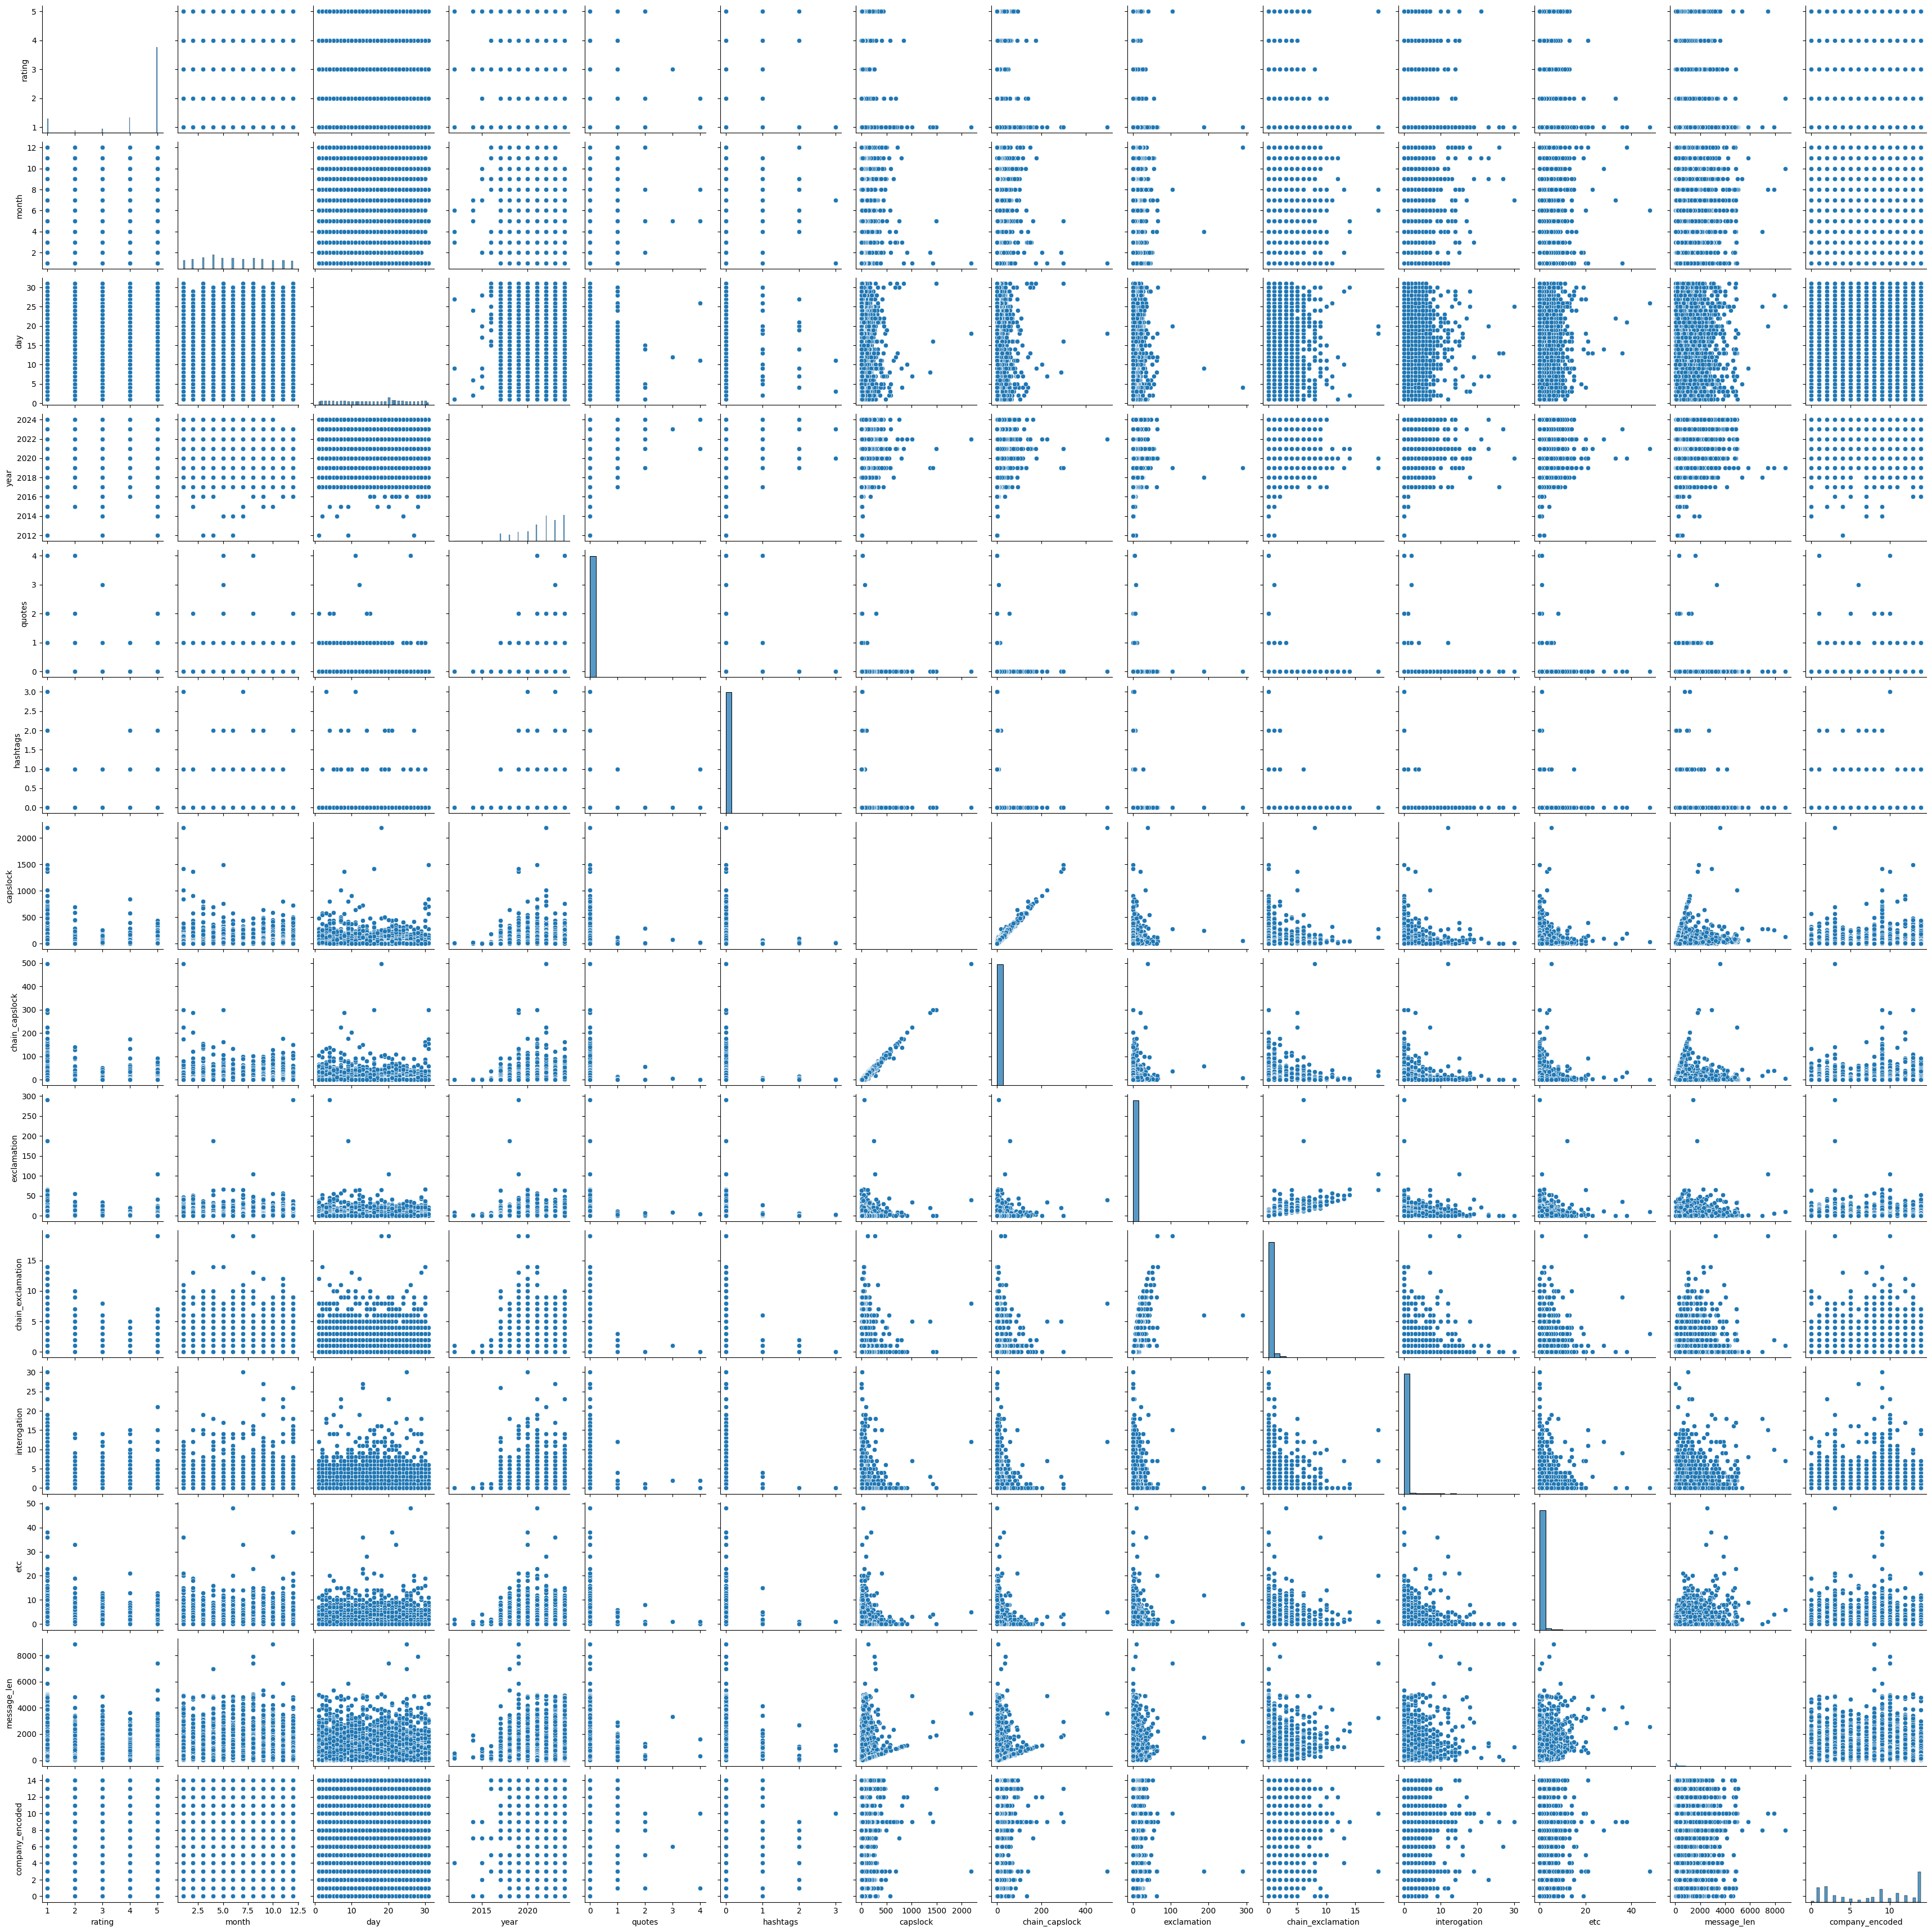

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Selection des variables numeriques
numerical_df = df.select_dtypes(include=['number'])

# Creation du pairplot
sns.pairplot(data = numerical_df)
plt.show()

Suite à la visualisation des distributions de nos données, nous regardons la corrélation entre nos variables numeriques.Nous avons beaucoup de variables ce ne nous permet pas de dégager une conclusion.
Nous tentons l'utilisations d'une autre matrice le heatmap afin d'affiner notre vison de notre dataset.

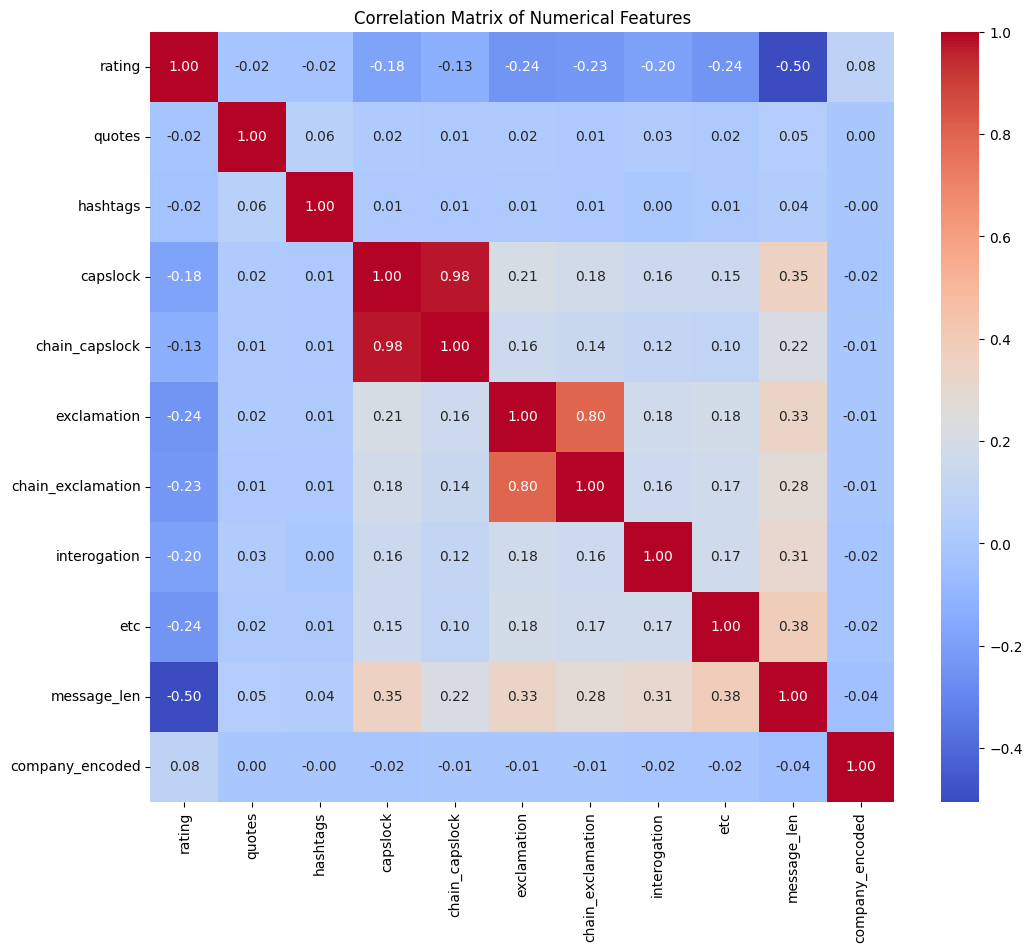

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# selection des variables explicatives numeriques
numerical_features = ['rating', 'quotes', 'hashtags', 'capslock', 'chain_capslock',
                      'exclamation', 'chain_exclamation', 'interogation', 'etc', 'message_len', 'company_encoded']

# calcul de la matrice de correlation
correlation_matrix = df[numerical_features].corr()

# affichage du heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


Nous constatons plusieurs corrélations positives et negatives, en particulier  entre la note est la longueur de message -0.50.
Nous décidons donc à présent suite a la visualisation du heatmap, en connaitre plus sur la longueur des avis (nombre de caractères) pour chaque catégorie de note (1 à 5) à l'aide d'un histogramme.

<Figure size 1200x800 with 0 Axes>

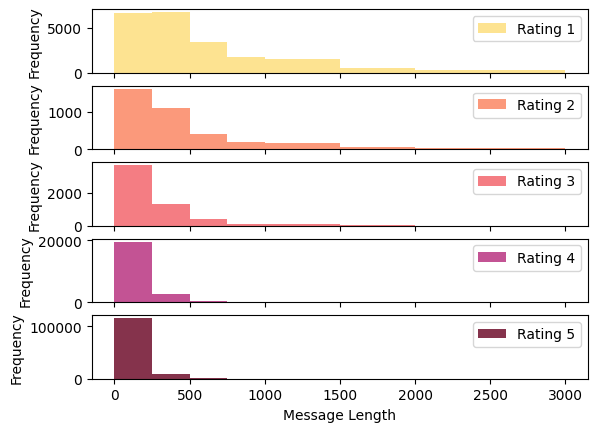

In [ ]:
plt.figure(figsize=(12, 8)) # taille du graphique
fig, ax = plt.subplots(nrows=5, ncols=1, sharex=True) # les 5 graphiques à tracer
bins = [0, 250, 500,750, 1000, 1500, 2000, 3000]

df[df.rating==1].message_len.plot(bins=bins, kind='hist', color='#FDDC76', label='Rating 1', alpha=0.8, ax=ax[0])
df[df.rating==2].message_len.plot(bins=bins, kind='hist', color='#FB805A', label='Rating 2', alpha=0.8, ax=ax[1])
df[df.rating==3].message_len.plot(bins=bins, kind='hist', color='#F25C64', label='Rating 3', alpha=0.8, ax=ax[2])
df[df.rating==4].message_len.plot(bins=bins, kind='hist', color='#B5287A', label='Rating 4', alpha=0.8, ax=ax[3])
df[df.rating==5].message_len.plot(bins=bins, kind='hist', color='#67001F', label='Rating 5', alpha=0.8, ax=ax[4])
plt.legend()
plt.xlabel("Message Length")


# Ajouter des légendes et des étiquettes
for ax in ax:
    ax.legend()
plt.xlabel("Message Length")
plt.show()

Nous constatons que la longeur des commentaires des clients satisfaits ayant obtenu la note 5 est très courte par rapport à celle des clients insatisfaits. Ce qui confirme la corrélation négative vu précédement, nous pouvons evisager d'utiliser cette variable pour améliorer notre modele si besoin.

Apres avoir exploré en détail les données numériques, nous souhaitons à présent visualiser une première fois les avis laissés par les clients avec la méthode du nuage de mots sans faire de nettoyage du corpus. Cela nous aidera peut être d'avantage dans la compréhension des mots les plus fréquents.

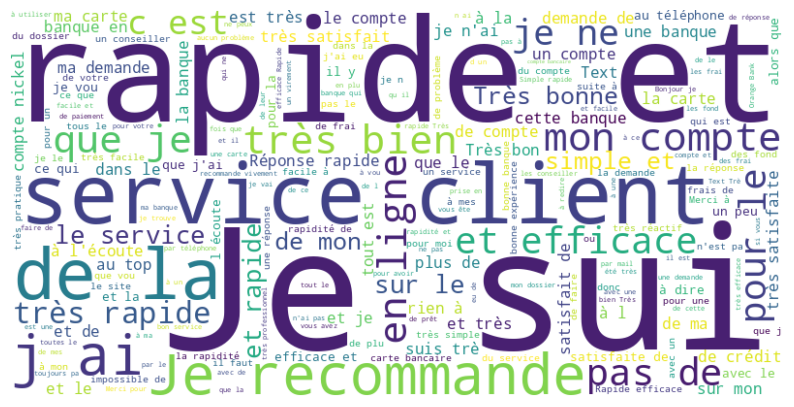

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

# nuage de mots pour visualiser les mots les plus fréquents
# Concatenation de tous les commentaires
text = " ".join(comment for comment in df.avis_global)

# Création du nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='white',random_state=42).generate(text)

# Affichage du nuage de mots ( Global)
#plt.title('Satisfaction globale')
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Le nuage de mots révèle des différences de caractères, des mots avec accents et des mots inutiles qui nous ont empêchés d'identifier des thèmes pertinents.

In [ ]:
# visualisez les valeurs numériques par note

df.describe()

#df1.groupby('rating').describe()

,rating,month,day,year,quotes,hashtags,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded
count,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.000000,179326.00000,179326.000000
mean,4.281588,6.277417,15.979512,2021.561932,0.000435,0.000268,5.427952,0.435079,0.414831,0.074563,0.053562,0.147681,177.43567,8.072789
std,1.337620,3.299282,8.746746,2.085772,0.025648,0.020585,17.351554,3.468181,1.883495,0.421545,0.471124,0.683501,258.44422,4.945267
min,1.000000,1.000000,1.000000,2012.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.00000,0.000000
25%,4.000000,4.000000,8.000000,2020.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.00000,3.000000
50%,5.000000,6.000000,17.000000,2022.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,104.00000,9.000000
75%,5.000000,9.000000,23.000000,2023.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,190.00000,13.000000
max,5.000000,12.000000,31.000000,2024.000000,4.000000,3.000000,2193.000000,496.000000,290.000000,19.000000,30.000000,48.000000,8837.00000,14.000000


Une standardisation des variables sera necessaire lors de nos modelisations lorsque l'on regarde les resultats, on observe des valeurs extremes.

# 4) Modélisation

**Import de notre base de données**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# lecture du dataframe
df = pd.read_csv("/content/drive/MyDrive/df_global.csv")

df.head(2)

Mounted at /content/drive


,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,hashtags,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,0,9,1,0,0,0,0,300,1
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,0,9,1,0,0,0,0,348,1


Nous tentons une première modélisation, sans retravailler les mots afin d'avoir une base de comparaison.
Pour cela nous utilisons les algorithmes supervisés suivants, que nous avons choisi en respectant les consignes présentes sur le site de Scikit-Learn. Pour cela nous avons pris en compte plusieurs critères: ( La taille, le type de donnée, le type prediction, la structure et le format des données), ce qui nous a orienté vers ces trois categories de modeles:

a) Naive Bayes avec les méthodes de BernouilliNB et Multinomial pour classer les avis (un classificateur qui suppose que l'effet d'une caractéristique particulière dans une classe est indépendant des autres caractéristiques).

b) KNN - peut être considéré comme un système de vote, dans lequel le label de classe majoritaire détermine le label de classe d'un nouveau point de données parmi ses « k » (où k est un nombre entier) voisins les plus proches dans l'espace des caractéristiques.

c) Logistic Regression - modèle statistique utilisé pour la classification et l'analyse prédictive pour estimer la probabilité qu'un événement se produise, en fonction d'un ensemble donné de variables indépendantes.

[Graphique visuel décisionel de choix des estimateurs de Scikit-Learn ](https://scikit-learn.org/stable/machine_learning_map.html)

In [ ]:
# importation des bibliothèques
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

data_model= df[['avis_global','rating']]

#decoupage des données
X_train, X_test, y_train, y_test = train_test_split(data_model['avis_global'], data_model['rating'], test_size=0.2, random_state=42)

Nous créons des pipelines pour associer le CountVectorizer (pour convertir le text en caractéristiques numériques), le StandardScaler (pour mettre à l'échelle les données pour qu'elles aient une moyenne zero et une variance constante) et les classificateurs : BernoulliNB, MultinomialNB, KNN, et la régression Logistique pour la classification.

Nous calculons par la suite l'Accuracy, la précision, le rappel et affichons le rapport de classification pour évaluer les performances de chaque modèle.


In [ ]:
# Modèle Bernoulli Naive Bayes avec la pipeline
bern_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('scaler', StandardScaler(with_mean=False)),
    ('bernoulli', BernoulliNB())
])

bern_pipeline.fit(X_train, y_train)
y_pred_bernoulli_nb = bern_pipeline.predict(X_test)
acc_bernoulli_nb = accuracy_score(y_test, y_pred_bernoulli_nb)

In [ ]:
# Modèle Multinomial Naive Bayes

multi_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('scaler', StandardScaler(with_mean=False)),
    ('Multinomials', MultinomialNB())
])

multi_pipeline.fit(X_train, y_train)
y_pred_multinomial_nb = multi_pipeline.predict(X_test)
acc_multinomial_nb = accuracy_score(y_test, y_pred_multinomial_nb)

In [ ]:
# Modéle KNN avec pipeline

knn_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('scaler', StandardScaler(with_mean=False)),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

In [ ]:
# Modéle Logistic regression avec pipeline

lr_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(max_iter=200))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

In [ ]:
# Résultats en synthèse
print("Neighbors Classifier:\n", classification_report(y_test, y_pred_knn))
print("Bernoulli Naive Bayes:\n", classification_report(y_test, y_pred_bernoulli_nb))
print("Multinomial Naive Bayes:\n", classification_report(y_test, y_pred_multinomial_nb))
print("LogisticRegression:\n", classification_report(y_test, y_pred_lr))
print("\nPrécision:")
print(f"Neighbors Classifier: {acc_knn:.2f}")
print(f"Bernoulli Naive Bayes: {acc_bernoulli_nb:.2f}")
print(f"Multinomial Naive Bayes: {acc_multinomial_nb:.2f}")
print(f"LogisticRegression: {acc_lr:.2f}")

Neighbors Classifier:
               precision    recall  f1-score   support

           1       0.57      0.31      0.40      4122
           2       0.08      0.04      0.05       737
           3       0.09      0.06      0.07      1088
           4       0.21      0.09      0.13      4528
           5       0.76      0.92      0.84     25391

    accuracy                           0.70     35866
   macro avg       0.34      0.28      0.30     35866
weighted avg       0.64      0.70      0.66     35866

Bernoulli Naive Bayes:
               precision    recall  f1-score   support

           1       0.62      0.72      0.66      4122
           2       0.06      0.00      0.00       737
           3       0.16      0.05      0.08      1088
           4       0.29      0.24      0.26      4528
           5       0.85      0.90      0.87     25391

    accuracy                           0.75     35866
   macro avg       0.39      0.38      0.38     35866
weighted avg       0.71      0

Nous pouvons constater que les scores extrêmes 1 et 5 sont mieux prédits que les scores intermédiaires. Les scores des 4 modèles de test sont moyens et peuvent être améliorés.

 On observe que les modèles de Bernouilli et de Régression Logistique sont les plus performants (75%), contrairement aux modèles Multinomial et KNN.

Par ailleurs, nous constatons que l'utilisation de certains modèles tels que K-Nearest-Neighbors est très lente sur une grande base de données.

Nous allons essayer plusieurs approches, telles que la binarisation des notes ( » target »), le nettoyage des mots et le rééquilibrage des données.

**Binarisation de la cible**

Pour simplifier la modélisation, nous avons choisi de regrouper les avis en 2 catégories, grâce à la visualisation de la longueur des mots. Nous avons choisi de considérer les notes 4 & 5 comme positives et les notes 1 & 2 comme négatives, et de ne pas conserver la note 3 car elle est peu représentative en volume et elle est intermédiaire dans la grille de notation.

Nous pouvons ensuite tester le rééchantillonnage de nos données en utilisant des méthodes telles que RandomUnderSampler, RandomOverSampler de la bibliothèque imblearn, ainsi que le rééquilibrage manuel.

In [2]:
#on sépare les notes en 2 catégories (-1,1,)
print(df.rating.unique())
df['rating_2'] = df.rating.replace([1,2,3,4,5],[-1,-1,1,1,1])

#enlever la note 3 du jeu de données car non significative en volume et dans l'entre deux
df = df[df.rating != 3]
df.shape

[5 4 2 1 3]


(173682, 20)

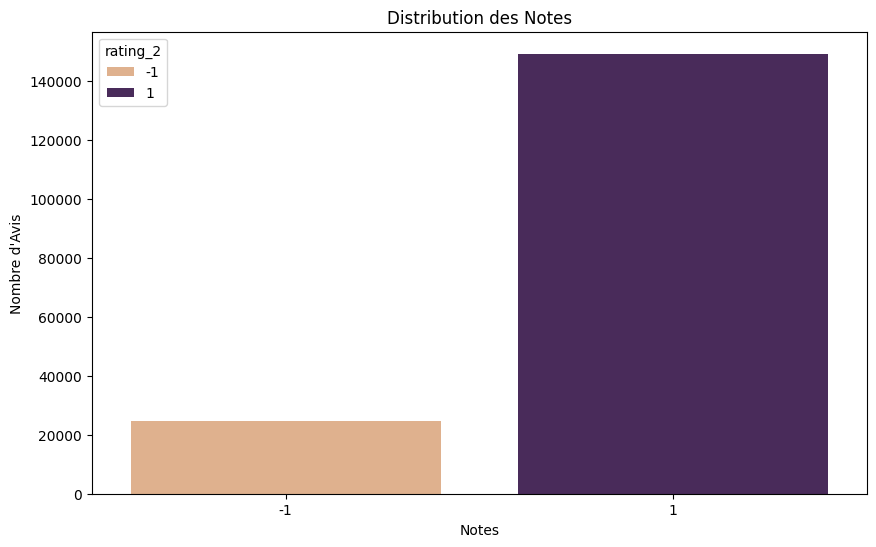

rating_2
 1    149107
-1     24575
Name: count, dtype: int64
rating_2
 1    0.858506
-1    0.141494
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='rating_2', data=df, palette='flare',hue='rating_2')
plt.title('Distribution des Notes')
plt.xlabel('Notes')
plt.ylabel('Nombre d\'Avis')
plt.show()
print(df.rating_2.value_counts())
print(df.rating_2.value_counts(normalize=True))

Nous constatons que le score négatif représente 14 % de notre ensemble de données.

**Nous testons a nouveau les modeles précédent avec la binarisation de la cible avant d'envisager un rééquilibrage des données**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Assuming `df` is already defined
data_model = df[['avis_global', 'rating_2']]

X_train, X_test, y_train, y_test = train_test_split(data_model['avis_global'], data_model['rating_2'], test_size=0.2, random_state=42)

# Fonction pour entraîner et évaluer chaque pipeline
def run_pipeline(pipeline_dict):
    name = pipeline_dict['name']
    pipeline = pipeline_dict['pipeline']

    print(f"--- {name} ---")

    # Entraîner le modèle
    pipeline.fit(X_train, y_train)

    # Évaluer sur l'ensemble de test
    y_pred = pipeline.predict(X_test)
    print(f"Classification Report:\n {classification_report(y_test, y_pred)}")

# Définition des pipelines
pipelines = [
    {
        'name': 'BernoulliNB',
        'pipeline': Pipeline([
            ('vectorizer', CountVectorizer(min_df=5)),
            ('scaler', StandardScaler(with_mean=False)),
            ('classifier', BernoulliNB(alpha=1.0, binarize=0.0))
        ])
    },
    {
        'name': 'MultinomialNB',
        'pipeline': Pipeline([
            ('vectorizer', CountVectorizer(min_df=5)),
            ('scaler', StandardScaler(with_mean=False)),
            ('classifier', MultinomialNB(alpha=1.0))
        ])
    },
    {
        'name': 'KNN',
        'pipeline': Pipeline([
            ('vectorizer', CountVectorizer(min_df=5)),
            ('scaler', StandardScaler(with_mean=False)),
            ('classifier', KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean'))
        ])
    },
    {
        'name': 'LogisticRegression',
        'pipeline': Pipeline([
            ('vectorizer', CountVectorizer(min_df=5)),
            ('scaler', StandardScaler(with_mean=False)),
            ('classifier', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000))
        ])
    },
]

# Exécuter chaque pipeline
for pipeline_dict in pipelines:
    run_pipeline(pipeline_dict)

--- BernoulliNB ---
Classification Report:
               precision    recall  f1-score   support

          -1       0.67      0.75      0.71      4800
           1       0.96      0.94      0.95     29937

    accuracy                           0.91     34737
   macro avg       0.81      0.85      0.83     34737
weighted avg       0.92      0.91      0.92     34737

--- MultinomialNB ---
Classification Report:
               precision    recall  f1-score   support

          -1       0.70      0.89      0.78      4800
           1       0.98      0.94      0.96     29937

    accuracy                           0.93     34737
   macro avg       0.84      0.91      0.87     34737
weighted avg       0.94      0.93      0.93     34737

--- KNN ---
Classification Report:
               precision    recall  f1-score   support

          -1       0.86      0.16      0.27      4800
           1       0.88      1.00      0.93     29937

    accuracy                           0.88     34737
  

En conclusion : La régression logistique est le modéle qui obtient le meilleur score 0.95. Cela va nous permettre grâce au bon résultat d'optimiser les parametres de ce modele et de rééquilibrer les données.

**Rééquilibrage des données**

Maintenant qu'un modele émerge nous pouvons aborder le sujet des ensembles de données déséquilibrés. Il y a trois pistes de travail:

a) générer de nouveaux échantillons dans les classes sous-représentées (Over Sampling).

Méthodes populaires de suréchantillonnage des classes minoritaires :

(i) RandomOverSampler - suréchantillonnage en dupliquant certains des échantillons originaux de la classe minoritaire

(ii) la technique de suréchantillonnage synthétique des minorités (SMOTE) - générer de nouveaux échantillons synthétiques diffèrent sans distinction entre les échantillons faciles et difficiles à classer à l'aide de la règle des voisins les plus proches

(iii) la méthode d'échantillonnage synthétique adaptative (ADASYN)- génération d'échantillons à côté des échantillons originaux qui sont mal classés à l'aide d'un classificateur k-voisins les plus proches

b) diminuer les échantillons dans les classes surreprésentées (under Sampling) par exemple avec la méthode Tomeklinks (Il s'agit d'une modification des plus proches voisins condensés (CNN) et peut être utilisée pour trouver les échantillons de données souhaités de la classe majoritaire qui ont la distance euclidienne la plus faible avec les données de la classe minoritaire, puis pour les supprimer).

c) combiner les deux méthodes précédentes pour optimiser les résultats dpar example avec la méthode SMOTE-TOMEK.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from imblearn import FunctionSampler
from imblearn.over_sampling import ADASYN, SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler,MaxAbsScaler

# Préparer les données
X = df[['avis_global']]
y = df['rating_2']

vectorisation = CountVectorizer()
X = vectorisation.fit_transform(X.values.ravel())# pour aplatir les valeurs en une seule dimension

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser le classificateur
classifier = LogisticRegression()
scaler = StandardScaler(with_mean=False)
# Définir les pipelines
pipeline = [
    make_pipeline(FunctionSampler(), scaler, classifier),
    make_pipeline(RandomOverSampler(random_state=42), scaler, classifier),
    make_pipeline(ADASYN(random_state=42),scaler, classifier),
    make_pipeline(SMOTE(random_state=42), scaler, classifier),
    make_pipeline(RandomUnderSampler(random_state=42),scaler, classifier),
    #make_pipeline(SMOTETomek(), scaler, classifier),
]

# Ajuster et évaluer les pipelines
for pipe in pipeline:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"Classification report for {pipe[0].__class__.__name__}:")
    print(classification_report(y_test, y_pred))


Classification report for FunctionSampler:
              precision    recall  f1-score   support

          -1       0.81      0.80      0.80      4800
           1       0.97      0.97      0.97     29937

    accuracy                           0.95     34737
   macro avg       0.89      0.88      0.89     34737
weighted avg       0.95      0.95      0.95     34737



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification report for RandomOverSampler:
              precision    recall  f1-score   support

          -1       0.77      0.80      0.78      4800
           1       0.97      0.96      0.96     29937

    accuracy                           0.94     34737
   macro avg       0.87      0.88      0.87     34737
weighted avg       0.94      0.94      0.94     34737

Classification report for ADASYN:
              precision    recall  f1-score   support

          -1       0.72      0.79      0.75      4800
           1       0.97      0.95      0.96     29937

    accuracy                           0.93     34737
   macro avg       0.84      0.87      0.86     34737
weighted avg       0.93      0.93      0.93     34737

Classification report for SMOTE:
              precision    recall  f1-score   support

          -1       0.73      0.79      0.76      4800
           1       0.97      0.95      0.96     29937

    accuracy                           0.93     34737
   macro avg    

Nous ne constatons pas d'amélioration de notre score, peux être notre méthode de standardisation n'est pas assez adapté. Nous voulons tester le MinMaxScaler cependant il ne gere pas les matrices, ce qui nous oriente sur le MaxAbsScaler.

In [ ]:
!pip install -U imbalanced-learn
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from imblearn import FunctionSampler
from imblearn.over_sampling import ADASYN, SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler,MaxAbsScaler

# Préparer les données
X = df[['avis_global']]
y = df['rating_2']
# Vectorisation de la colonne 'avis_global'
vectorisation = CountVectorizer()
X = vectorisation.fit_transform(X.values.ravel())

# Vectorisation de la colonne 'avis_global'
#vectorizer = CountVectorizer()
#avis_vectorized = vectorizer.fit_transform(df['avis_global'])

# Ajout des vecteurs comme nouvelles colonnes dans le DataFrame
#avis_df = pd.DataFrame(avis_vectorized.toarray(), columns=vectorizer.get_feature_names_out())
#df = pd.concat([df.reset_index(drop=True), avis_df.reset_index(drop=True)], axis=1)

# Sélection des features et du target
#X = df.drop(['rating', 'rating_2', 'avis_global'], axis=1) # On retire aussi 'avis_global' des features
#y = df['rating_2']
#X = X.select_dtypes('number')

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser le classificateur
classifier = LogisticRegression()
scaler = MaxAbsScaler()
# Définir les pipelines
pipeline = [
    make_pipeline(FunctionSampler(), scaler, classifier),
    make_pipeline(RandomOverSampler(random_state=42), scaler, classifier),
    make_pipeline(ADASYN(random_state=42),scaler, classifier),
    make_pipeline(SMOTE(random_state=42), scaler, classifier),
    make_pipeline(RandomUnderSampler(random_state=42),scaler, classifier),
    #make_pipeline(SMOTETomek(), scaler, classifier),
]

# Ajuster et évaluer les pipelines
for pipe in pipeline:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"Classification report for {pipe[0].__class__.__name__}:")
    print(classification_report(y_test, y_pred))


Classification report for FunctionSampler:
              precision    recall  f1-score   support

          -1       0.94      0.83      0.88      4800
           1       0.97      0.99      0.98     29937

    accuracy                           0.97     34737
   macro avg       0.95      0.91      0.93     34737
weighted avg       0.97      0.97      0.97     34737

Classification report for RandomOverSampler:
              precision    recall  f1-score   support

          -1       0.84      0.92      0.88      4800
           1       0.99      0.97      0.98     29937

    accuracy                           0.97     34737
   macro avg       0.92      0.95      0.93     34737
weighted avg       0.97      0.97      0.97     34737

Classification report for ADASYN:
              precision    recall  f1-score   support

          -1       0.74      0.91      0.82      4800
           1       0.98      0.95      0.97     29937

    accuracy                           0.94     34737
   mac

 Nous constatons que les différentes méthodes de rééquilibrages nous permettent d'améliorer le score de notre prédiction, nous tentons un rééquilibrage manuel également pour faire un choix.

Rééquilibrage Manuel

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler

#selection des echantillon de chaque catégorie
df_inliers = df[df['rating_2'] == 1]
df_outliers = df[df['rating_2'] == -1]
df_inliers = df_inliers[:15000]
df_outliers = df_outliers[:15000]
df1 = pd.concat([df_inliers, df_outliers])

# Vectorisation de la colonne 'avis_global'
vectorizer = CountVectorizer()
avis_vectorized = vectorizer.fit_transform(df1['avis_global'])

# Ajout des vecteurs comme nouvelles colonnes dans le DataFrame
#avis_df = pd.DataFrame(avis_vectorized.toarray(), columns=vectorizer.get_feature_names_out())
#df1 = pd.concat([df1.reset_index(drop=True), avis_df.reset_index(drop=True)], axis=1)

# Sélection des features et du target
feats = df.drop(['rating', 'rating_2', 'avis_global'], axis=1) # On retire aussi 'avis_global' des features
target = df['rating_2']
feats = feats.select_dtypes('number')

#df1.rating_2.value_counts()

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(feats, target, test_size=0.2, random_state=42)

# Normalisation des features
mas = MaxAbsScaler()
X_train = mas.fit_transform(X_train)
X_test = mas.transform(X_test)

# Modèle de régression logistique
model = LogisticRegression()
model.fit(X_train, y_train)

# Évaluation du modèle
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9014883265682125
Precision: 0.9078101448829555
Recall: 0.9858035207268597
              precision    recall  f1-score   support

          -1       0.81      0.38      0.51      4800
           1       0.91      0.99      0.95     29937

    accuracy                           0.90     34737
   macro avg       0.86      0.68      0.73     34737
weighted avg       0.89      0.90      0.89     34737



Nous notons les bonnes performances, qui sont cependant moins bonnes que le RandomOverSampler. Nous continurons donc avec la méthode RandomOverSampler.

**Recherche des hyperparametres de la régression logistique avec RandomOverSampler**

In [ ]:
#Test et récupération des meilleurs parametres avec la solutions 1 RAndomOverSampler

In [3]:
!pip install -U imbalanced-learn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


# Séparation des features et du target
X = df['avis_global']
y = df['rating_2']

#transformation du texte en vecteur
vectorisation = CountVectorizer()
X = vectorisation.fit_transform(X.values.ravel())

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définition des pipelines
pipelines = [
    {
        'name': 'LogisticRegression',
        'pipeline': ImbPipeline([
            ('sampler', RandomOverSampler(random_state=42)),
            ('scaler', MaxAbsScaler()),
            ('classifier', LogisticRegression(random_state=42))
        ]),
        'param_grid': {
            'classifier__C': [0.001, 0.01, 0.1, 1.0, 2.0,100],
            'classifier__solver': ['lbfgs', 'liblinear'],
            'classifier__max_iter': [200, 500, 1000, 2000]
        }
    }
]

# initialisation de la dictionnaire best_params_dict
best_params_dict = {}

# Utilisation de GridSearch pour chaque pipeline (Modèle)
for pipeline_dict in pipelines:
    name = pipeline_dict['name']
    pipeline = pipeline_dict['pipeline']
    param_grid = pipeline_dict['param_grid']

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    print(f"--- {name} ---")
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score:", grid_search.best_score_)

    # Stockage des meilleurs paramètres dans le dictionnaire
    best_params_dict[name] = grid_search.best_params_

    # Évaluation sur le jeu de test
    y_pred = grid_search.predict(X_test)
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

# Affichage des meilleurs paramètres des modèles
print("\n--- Best Parameters for All Models ---")
for model_name, best_params in best_params_dict.items():
    print(f"{model_name}: {best_params}")


--- LogisticRegression ---
Best parameters: {'classifier__C': 2.0, 'classifier__max_iter': 200, 'classifier__solver': 'lbfgs'}
Best cross-validation score: 0.9646118967936953
Classification Report:
              precision    recall  f1-score   support

          -1       0.84      0.92      0.88      4800
           1       0.99      0.97      0.98     29937

    accuracy                           0.97     34737
   macro avg       0.92      0.95      0.93     34737
weighted avg       0.97      0.97      0.97     34737


--- Best Parameters for All Models ---
LogisticRegression: {'classifier__C': 2.0, 'classifier__max_iter': 200, 'classifier__solver': 'lbfgs'}


Suite au calcul des hyperparametres nous venons de trouver le meilleurs resultats de notre model.

Nous testons notre modèle en lui proposant un nouveau commentaire à analyser

In [7]:
commentaires = ["Toujours aucune réponse, après que vous m'ayez demander plus d'informations, cela est de trop la prochaine étape sera de déposer une plainte tout simplement à votre encontre. Je remarque que je ne suis pas la seule dans cette histoire qui ressemble trait pour trait à une arnaque bien ficelée......",
               "Une gestion facile et rapide de ses comptes.La possibilité de souscrire à une assurance vie en quelques clics.Notre argent finance des projets positifs en lien avec nos objectifs climatiques.Je recommande fortement !Quittons les banques traditionnelles ultra polluantes !",
                "Des arnaqueurs à l’exposant 20. Depuis 2 mois mon compte a été bloqué. J’ai envoyé tous les justificatifs pourtant aucun effort de retour. L’application reste toujours bloqué avec le même message. Je vous donne quelques jours encore pour avoir mon compte débloqué et recevoir mon virement sinon vous saurez que ce n’est pas à tous les clients on fait ces bails. Vous ne respectez aucune réglementation en terme de délai de réponse pour un compte bloqué. Vous êtes prévenus",
                "je viens enfin de récupérer mon traitement apres de grosses difficultés dans la livraison ( UPS n’est pas des plus efficae). au dela de cet incident le suivi effectué par Marhis est top. il a ete disponible, il a suivi l’expédition. j’ai reussi à recevoir mon traitement alors 1000 merci à lui. Les informations fournies par Mathis sont claires désormais la prochaine etape est la prise de rdv pour commencer le traitement."
]

commentaires_tokenizer = vectorisation.transform(commentaires)
grid_search.predict(commentaires_tokenizer.toarray())

array([-1,  1, -1,  1])

Nous constatons que le modèle prédit bien les sentiments que dégagent des commentaires positifs et négatifs.

----
**La partie modélisation nous à permi de calculer notre meilleur prédiction, nous devons maintenant nous concentrer sur la détection des thématiques, pour cela nous avons besoin de retravailler les avis**

**Nettoyage des avis**

Une fois l'ensemble de données rééquilibré, nous allons maintenant traiter la colonne avis_global pour supprimer les stopwords, les espaces superflus, les caractères spéciaux, etc. à l'aide des bibliothèques Regex (Regular Expressions) et NLTK.(Natural Language Tool Kit).

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import re


def cleaner(text):
    text = re.sub(r'[àáâãäå]', 'a', text)  # Remplacer les accents par 'a'
    text = re.sub(r'[èéêë]', 'e', text)  # Remplacer les accents par 'e'
    text = re.sub(r'[ìíîï]', 'i', text)  # Remplacer les accents par 'i'
    text = re.sub(r'[òóôõö]', 'o', text)  # Remplacer les accents par 'o'
    text = re.sub(r'[ùúûü]', 'u', text)  # Remplacer les accents par 'u'
    text = re.sub(r'[ýÿ]', 'y', text)  # Remplacer les accents par 'y'
    text = re.sub(r'[ç]', 'c', text)  # Remplacer les accents par 'c'
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)  # Supprimer les chiffres
    text = re.sub(r'\s+', ' ', text)  # Remplacer les espaces multiples par un seul espace
    text = text.lower().strip()  # Mettre en minuscule et supprimer les espaces en début et fin
    return text

# Appliquer la fonction de nettoyage sur 'avis_global'
df['avis_clean'] = df['avis_global'].apply(cleaner)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


suppression des stop words : nettoyage des carateres et les mots vides n'apportant rien pour l'analyse des catégories

In [ ]:
from nltk.corpus import stopwords
# Un fois caractère de sentiment, je fiabilise et je supprime les accents et j'enlève les stop words
stop_words = set(stopwords.words('french'))
stop_words.update(['text','.', ',', '"', "'", '?', '!', ':', ';', '(',')', '[',']', '{', '}',
                   'bien','suite','encore', 'bonjour', 'trouve', 'plus', 'aujourdhui', 'aujourd hui', 'younited', 'revolut', 'qonto', 'cofidis', 'boursorama',
                   'enorme', 'etait', 'alors', 'ni', 'dit', 'toujours', 'fait', 'dire', 'non', 'cette', 'orange', 'oney', 'nickel', 'fortuneo', 'floabank',
                   'autre', 'cela', 'tous', 'tout', 'ca', 'car', 'tou', 'alor', 'sans', 'peu', 'foi','fois', 'n26', 'monabanq', 'mafrenchbank', 'hellobank',
                   'donc','très','no','si','a','la','ok','ont','m','j','s','d','l','être','je','assez','tres', 'bank', 'hello',
                   'trés','je','suis','rien','surtout','oney','nickel','aucun','meme','comme','plu','quand','banque',
                   'n26','boursorama','boursobank','bourso','cad','floa','bforbank','french','qonto','revolut','younited_credit','orange bank','cofidis','deja',
                   'aussi','jamai','leurs','leur','bon','bons','chez','merci','avoir','depuis','ete','oui','apres','super','parfait','contre'])


#text = ' '.join([word for word in text.split() if word not in stop_words and len(word)>1])  # Supprimer les stop words text = ' '.join([word for word in text.split() if word not in stop_words and len(word) > 4])
def stop_words_cleaner(text):
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['avis_clean'] = df['avis_clean'].apply(stop_words_cleaner)

Sauvegarde des travaux sur les mots

In [ ]:
#verification des nettoyages stop words et caractères
df.head(2)

,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,...,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded,rating_2,avis_clean
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,...,9,1,0,0,0,0,300,1,1,carte piratee vacances indonesie avis utilisat...
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,...,9,1,0,0,0,0,348,1,1,application bancaire fluide application bancai...


**Nous verifions que les traitement n'ont pas altéré notre data frame**

In [ ]:
df.isna().sum()

,0
ID,0
verif,0
rating,0
Date,0
month,0
day,0
year,0
company,0
avis_global,0
quotes,0


Nous voyons que la suppressions de certains ont créé des avis vide, nous allons réajuster le jeu de donnée

In [ ]:
df = df.dropna()

df.isna().sum()

,0
ID,0
verif,0
rating,0
Date,0
month,0
day,0
year,0
company,0
avis_global,0
quotes,0


In [ ]:
df.shape

(173682, 21)

Cette suppresion des valeurs necessite un réajustement de l'index du data

In [ ]:
df.reset_index(drop = True)

,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,...,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded,rating_2,avis_clean
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,...,9,1,0,0,0,0,300,1,1,carte piratee vacances indonesie avis utilisat...
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,...,9,1,0,0,0,0,348,1,1,application bancaire fluide application bancai...
2,Bad Wolf,Non vérifié,5,2024-10-08,10,8,2024,Boursorama,Parfait ! Je ne peux que recommander BoursoBan...,0,...,10,0,1,0,0,0,466,1,1,peux recommander beaucoup reticents banques li...
3,Jean-Paul Cauchin,Sur invitation,4,2024-10-07,10,7,2024,Boursorama,Connexion impossible La connexion sur l'applic...,0,...,6,0,0,0,0,1,387,1,1,connexion impossible connexion application mob...
4,Sophie R,Sur invitation,5,2024-10-08,10,8,2024,Boursorama,Je suis assez satisfaite des services… Je suis...,0,...,5,0,0,0,0,0,243,1,1,satisfaite services satisfaite services pourqu...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173677,saft,Non vérifié,1,2018-06-06,6,6,2018,Cofidis,dés que vous tentez d'effectuez des… COFIDIS F...,0,...,75,11,13,4,0,1,1214,2,-1,tentez effectuez fraudeur tentez effectuez ach...
173678,Zammit,Non vérifié,1,2018-02-14,2,14,2018,Cofidis,Ils vous harcèlent par mail ou courrier… Ils v...,0,...,2,0,0,0,0,0,229,2,-1,harcelent mail courrier harcelent mail courrie...
173679,Joel,Non vérifié,4,2018-05-02,5,2,2018,Cofidis,Cofidis + Amazon ça marche plutôt bien. En gén...,0,...,19,1,1,0,0,0,754,2,1,amazon marche plutot generale poste avis conte...
173680,Suzanne Rozec,Non vérifié,1,2017-01-25,1,25,2017,Cofidis,une perte de temps pour une offre exorbitante ...,0,...,2,0,0,0,0,0,380,2,-1,perte temps offre exorbitante inappropriee vou...


In [ ]:
df.to_csv('/content/drive/MyDrive/df_clean.csv', index=False)

Nous pouvons à présent afficher le nuage de mots suite à nos traitements des avis pour voir si notre travail s'est déroulé correctement.

In [ ]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 3.6 MB/s eta 0:00:00


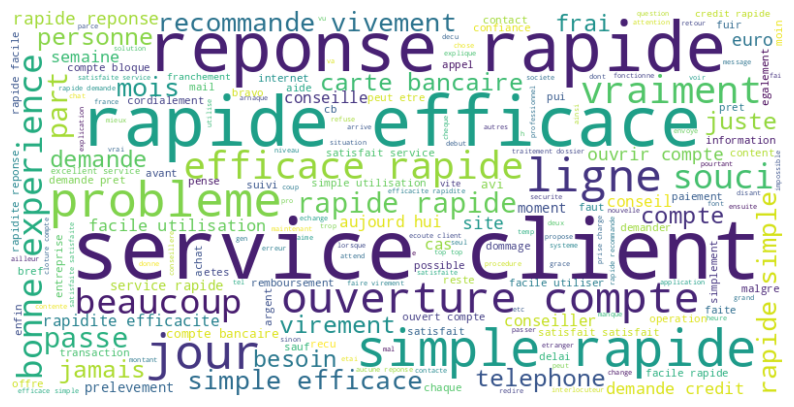

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
# Deuxiéme visualization par Word Cloud après le nettoyage

# Concatenation de tous les commentaires
text2 = " ".join(comment for comment in df.avis_clean)

# Création du nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='white',random_state=42).generate(text2)

# Affichage du nuage de mots ( Global)
#plt.title('Satisfaction globale')
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Malgré le nettoyage de notre corpus, nous constatons que la première visualisation des nuages de mots ne nous permet pas de hiérarchiser les sujets et de mettre en évidence ceux qui sont importants pour les commentaires négatifs et positifs.
Nous allons donc essayer de visualiser les nuages de mots pour les 2 catégories de commentaires pour voir si nous pouvons capturer les sujets principaux dans les catégories respectives.

On génére donc un word cloud pour la catégorie des notes positives et les notes negatives.

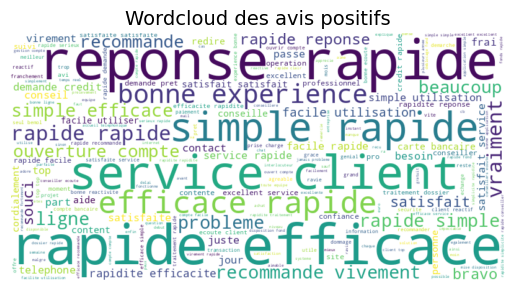

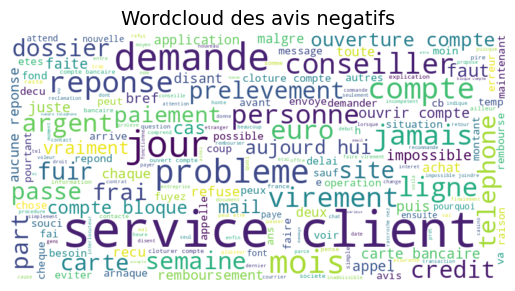

In [ ]:
# instanciation des avis_positifs et négatifs
avis_positifs = df[df['rating_2'] == 1]['avis_clean']
avis_negatifs = df[df['rating_2'] == -1]['avis_clean']

# Concatenation de tous les commentaires positifs et négatifs
df_avis = pd.concat([avis_positifs, avis_negatifs])

# réinitialiser les index
df_avis = df_avis.reset_index(drop=True)
df_avis

# fonction pour générer le word cloud
def generate_wordcloud(text, titre):
  all_avis = " ".join(comment for comment in text)
  wordcloud = WordCloud(width=800, height=400, background_color='white',random_state=42).generate(all_avis)

  #plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(titre, fontsize = 14)
  plt.axis('off')
  plt.show()

# Affichage des nuages de mots
plt.title('Wordcloud des avis positifs')
generate_wordcloud((avis_positifs), 'Wordcloud des avis positifs')
generate_wordcloud((avis_negatifs), 'Wordcloud des avis negatifs')

Pour les commentaires positifs, nous pouvons identifier quelques thématiques liées à un bon et rapide service à la clientèle, une bonne expérience et même à des recommandations.

Pour les commentaires négatifs, les sujets ne sont pas explicites mais on peut commencer à identifier des problèmes liés au service client etc....

Dans les deux catégories, il n'est pas évident d'identifier les sujets principaux et réels de satisfaction ou d'insatisfaction.

Afin d'aller plus loin, nous allons essayer d'autres méthodes telles que LDA et le Bertopics.

Dans cette partie, nous allons tokeniser (diviser en plus petits morceaux - mots) notre corpus pour créer une matrice (Document Term Matrix). Nous utiliserons pour cela le CountVectorizer de scikit-learn, où chaque ligne représentera un document différent et chaque colonne un mot différent (représenter un document par le nombre d'occurrences des mots qu'il contient = bag of words)

# Topic Modeling avec LDA (Latent Dirichlet Allocation)

Une technique d'apprentissage non supervisée qui vise à découvrir les sujets latents et les proportions correspondates de chaque  cas dans chaque document.

In [ ]:
#Pour chargement du Dataframe
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# lecture du dataframe
df = pd.read_csv("/content/drive/MyDrive/df_clean.csv")

df.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,...,capslock,chain_capslock,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded,rating_2,avis_clean
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,...,9,1,0,0,0,0,300,1,1,carte piratee vacances indonesie avis utilisat...
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,...,9,1,0,0,0,0,348,1,1,application bancaire fluide application bancai...


In [ ]:
df.shape

(173682, 21)

In [ ]:
# le topic modeling pour connaitre les themes les plus importants

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Vectorisation des avis
vectorizer = CountVectorizer()
df['avis_clean']=df['avis_clean'].astype(str)
dtm = vectorizer.fit_transform(df['avis_clean'])

# Creation du LDA modele
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(dtm)

# Recuperation des mots pour chaque théme.
for index, topic in enumerate(lda.components_):
    print(f"Top words for topic {index}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]) # Adjust the number of top words to display

# Transformation des docuements en matrice de distribution
topic_results = lda.transform(dtm)

# Ajout de la catégorie de topics dans le DataFrame
df['topic_distribution'] = list(topic_results)

Top words for topic 0:
['confiance', 'juste', 'seul', 'ligne', 'meilleure', 'banques', 'facilite', 'simplicite', 'efficacite', 'rapidite']
Top words for topic 1:
['clair', 'facile', 'fonds', 'serieux', 'dossier', 'recommande', 'simple', 'reponse', 'efficace', 'rapide']
Top words for topic 2:
['argent', 'demande', 'telephone', 'mail', 'reponse', 'faire', 'mois', 'client', 'service', 'compte']
Top words for topic 3:
['nan', 'annees', 'jamais', 'probleme', 'soucis', 'services', 'contente', 'client', 'satisfait', 'service']
Top words for topic 4:
['reactif', 'probleme', 'agreable', 'equipe', 'bonne', 'conseillers', 'accueil', 'conseiller', 'top', 'ecoute']
Top words for topic 5:
['recommande', 'ligne', 'excellent', 'simple', 'utilisation', 'experience', 'application', 'pratique', 'facile', 'bonne']
Top words for topic 6:
['reactivite', 'qualite', 'beaucoup', 'pret', 'recommande', 'credit', 'demande', 'rapidement', 'satisfaite', 'service']
Top words for topic 7:
['avis', 'recommande', 'recu

Nous notons que la vectorisation avec le CountVectorizer ne permet pas de pondéré les poids de mots dans les docuements, contrairement au TFID.

In [ ]:
# le topic modeling pour connaitre les themes les plus importants

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorisation des avis
vectorizer = TfidfVectorizer()  #
df['avis_clean']=df['avis_clean'].astype(str)
dtm_tfidf = vectorizer.fit_transform(df['avis_clean'])

# Creation du LDA modele
lda = LatentDirichletAllocation(n_components=10, random_state=42) # Adjust n_components (number of topics)
lda.fit(dtm)

# Recuperation des mots pour chaque théme.
for index, topic in enumerate(lda.components_):
    print(f"Top words for topic {index}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]) # Adjust the number of top words to display

# Transformation des docuements en matrice de distribution
topic_results = lda.transform(dtm)

# Ajout de la catégorie de topics dans le DataFrame
df['topic_distribution'] = list(topic_results)

Top words for topic 0:
['ecoute', 'conseil', 'taux', 'precis', 'competent', 'agreable', 'personnel', 'rapide', 'clair', 'accueil']
Top words for topic 1:
['impossible', 'argent', 'jours', 'mois', 'faire', 'demande', 'service', 'client', 'carte', 'compte']
Top words for topic 2:
['vraiment', 'meilleure', 'compte', 'ras', 'ligne', 'client', 'services', 'top', 'service', 'satisfait']
Top words for topic 3:
['utiliser', 'securise', 'application', 'redire', 'utilisation', 'simple', 'rapide', 'pratique', 'excellent', 'facile']
Top words for topic 4:
['rapidement', 'facilite', 'recommande', 'dossier', 'demande', 'rapide', 'simplicite', 'credit', 'efficacite', 'rapidite']
Top words for topic 5:
['paiement', 'seul', 'trop', 'pratique', 'juste', 'dommage', 'frais', 'contente', 'carte', 'compte']
Top words for topic 6:
['service', 'charge', 'ecoute', 'reactivite', 'rapide', 'prise', 'experience', 'reactif', 'nan', 'bonne']
Top words for topic 7:
['demande', 'serieux', 'content', 'professionnel', 

On peut voir émerger des thématiques, mais cela est complexe dès que l'on veut comparer les themes ensemble. On va réduire le nombre de thématiques pour améliorer la compréhension.

Nous testons une deuxième méthode intéractive pour la visualialisation des thèmes avec la LDA

In [ ]:
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('punkt')
nltk.download('punkt_tab')

# Application de tokenizer sur 'avis_clean' et transformation en texte
df['avis_clean']=df['avis_clean'].astype(str)

df['avis_tokenized'] = df['avis_clean'].apply(lambda x: word_tokenize(x, language='french'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Travail préparatoire à la visualisation

In [ ]:
# importer les packages + librairies necessaires à LDA
!pip install pyLDAvis

import pyLDAvis # pour interpréter les sujets dans Topic model

import gensim # bibliothèque open-source pour la modélisation thématique non supervisée, l'indexation de documents
import pyLDAvis.gensim_models # pour la visualisation interactive des modèles de sujets
from gensim.utils import simple_preprocess
import gensim.corpora as corpora # pour la mise en rapport de mots avec des nombres entiers

import warnings
warnings.filterwarnings("ignore")

# créer une liste à partir de la colonne 'avis_global
avis_globalToList = df['avis_tokenized'].tolist()

# créer un DTM (Document Term Matrix) tableau de tokens à partir de la nouvelle colonne
# dictionnaire
id2word = corpora.Dictionary(avis_globalToList)

# créer un corpus & bag of words
texts = avis_globalToList
corpus = [id2word.doc2bow(text) for text in texts]

In [ ]:
len(id2word)

53324

Définition des paramétres et affichage des thémes avec pondérations des mots

In [ ]:
from pprint import pprint

# définir le nombre de sujets (clusters ?)
num_topics = 8

# générer le model LDA
lda_model_8=gensim.models.LdaMulticore(corpus=corpus, id2word=id2word, num_topics=num_topics,passes=10)

# imprimer les mots clés dans les 8 clusters
pprint(lda_model_8.print_topics())

doc_lda = lda_model_8[corpus]

[(0,
  '0.035*"service" + 0.031*"rapidite" + 0.028*"client" + 0.025*"satisfaite" + '
  '0.023*"top" + 0.014*"efficacite" + 0.011*"ligne" + 0.011*"vraiment" + '
  '0.010*"compte" + 0.009*"reponse"'),
 (1,
  '0.045*"rapide" + 0.036*"credit" + 0.024*"demande" + 0.020*"reponse" + '
  '0.012*"rapidement" + 0.012*"recommande" + 0.010*"serieux" + 0.009*"dossier" '
  '+ 0.009*"reactif" + 0.007*"organisme"'),
 (2,
  '0.027*"compte" + 0.022*"bonne" + 0.016*"rapide" + 0.013*"simple" + '
  '0.012*"pratique" + 0.012*"utilisation" + 0.011*"efficace" + 0.009*"service" '
  '+ 0.008*"carte" + 0.007*"frais"'),
 (3,
  '0.045*"compte" + 0.027*"facile" + 0.015*"rapide" + 0.014*"demande" + '
  '0.009*"client" + 0.009*"ouverture" + 0.008*"reponse" + 0.008*"service" + '
  '0.007*"dossier" + 0.006*"faire"'),
 (4,
  '0.021*"excellent" + 0.018*"service" + 0.018*"rapide" + 0.017*"carte" + '
  '0.010*"demande" + 0.009*"rapidite" + 0.009*"probleme" + 0.008*"recommande" '
  '+ 0.008*"paiement" + 0.007*"client"'),
 (

Nous souhaitons maintenant vérifier la cohérence du modèle en évaluant le degré de similarité sémantique entre les mots les mieux notés dans les thèmes.

(pour un bon modèle LDA la cohérence doit être comprise entre 0.4 et 0.7 cf. https://larevueia.fr/latent-dirichlet-allocation-topic-modeling-en-python/ )


In [ ]:
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(model=lda_model_8, texts=avis_globalToList, dictionary=id2word)
coherence_lda = coherence_model_lda.get_coherence()
coherence_lda_rounded = round(coherence_lda, 1)
print('Coherence Score: ', coherence_lda_rounded)

Coherence Score:  0.5


On voit que le test réalisé valide cette condition. Ce qui nous permet de visualiser par un graphique nos thématiques.

In [ ]:
import pyLDAvis.gensim_models as gensimvis
#vis_data = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis_data = gensimvis.prepare(lda_model_8, corpus, id2word)
pyLDAvis.display(vis_data)

Les sujets nous semblent encore trop nombreux, nous essayons de réduire d'avantage le nombre de sujets à 5 afin d'affiner et de mieux comprendre les thèmes.

In [ ]:
#On teste avec moins de topics
from pprint import pprint

# définir le nombre de sujets (clusters)
num_topics = 5

# générer le model LDA
lda_model_5=gensim.models.LdaMulticore(corpus=corpus, id2word=id2word, num_topics=num_topics, passes=10)

# imprimer les mots clés dans les 15 clusters
pprint(lda_model_5.print_topics())

doc_lda_5 = lda_model_5[corpus]

[(0,
  '0.042*"compte" + 0.023*"rapide" + 0.016*"top" + 0.014*"recommande" + '
  '0.012*"simple" + 0.011*"client" + 0.011*"reponse" + 0.010*"service" + '
  '0.010*"vraiment" + 0.008*"virement"'),
 (1,
  '0.066*"rapide" + 0.026*"efficace" + 0.025*"reponse" + 0.015*"demande" + '
  '0.014*"dossier" + 0.014*"service" + 0.011*"facile" + 0.009*"simple" + '
  '0.009*"compte" + 0.009*"pret"'),
 (2,
  '0.024*"simple" + 0.023*"bonne" + 0.020*"rapide" + 0.019*"facile" + '
  '0.015*"utilisation" + 0.011*"compte" + 0.011*"demande" + 0.010*"recommande" '
  '+ 0.010*"pratique" + 0.010*"frais"'),
 (3,
  '0.023*"rapide" + 0.020*"service" + 0.019*"satisfait" + 0.016*"efficace" + '
  '0.015*"carte" + 0.014*"ecoute" + 0.014*"ligne" + 0.011*"client" + '
  '0.011*"compte" + 0.009*"experience"'),
 (4,
  '0.018*"compte" + 0.014*"service" + 0.010*"carte" + 0.009*"rapidite" + '
  '0.009*"client" + 0.008*"demande" + 0.008*"probleme" + 0.007*"reponse" + '
  '0.006*"faire" + 0.006*"credit"')]


Vérification de la cohérence du modèle en réduisant le nombre des clusters.

In [ ]:
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(model=lda_model_5, texts=avis_globalToList, dictionary=id2word)
coherence_lda = coherence_model_lda.get_coherence()
coherence_lda_rounded = round(coherence_lda, 1)
print('Coherence Score: ', coherence_lda_rounded)

Coherence Score:  0.4


In [ ]:
import pyLDAvis.gensim_models as gensimvis
#vis_data = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis_data = gensimvis.prepare(lda_model_5, corpus, id2word)
pyLDAvis.display(vis_data)

Les thèmes qui resortent:

1-Demande de credit
2-Service a la clientèle,Amabilité,écoute
3-Rapidité de la réponse, qualité de service
4-Déblocage de Fonds
5-Recomandation


 Pour cette section, nous voulons séparer et afficher les mots entre les avis positifs et négatifs pour chaque entreprise.

In [ ]:
# separer les themes entre les avis positifs et negatifs pour chaque entreprise

from collections import Counter

def extract_themes(reviews):
  reviews = reviews.astype(str)
  all_words = ' '.join(reviews).split()
  word_counts = Counter(all_words)
  themes = [word for word, count in word_counts.most_common(10)]
  return themes

# Obtenir la liste des entreprises uniques
companies = df['company'].unique()

for company in companies:
  # Filtrer les avis pour l'entreprise actuelle
  company_reviews = df[df['company'] == company]

  # Séparer les avis positifs et négatifs pour l'entreprise
  positive_reviews = company_reviews[company_reviews['rating_2'] == 1]['avis_clean']
  negative_reviews = company_reviews[company_reviews['rating_2'] == -1]['avis_clean']

  # Extraire les thèmes pour les avis positifs et négatifs de l'entreprise
  positive_themes = extract_themes(positive_reviews)
  negative_themes = extract_themes(negative_reviews)

  # Afficher les résultats pour l'entreprise
  print(f"Entreprise: {company}")
  print("  Thèmes Positifs:", positive_themes)
  print("  Thèmes Négatifs:", negative_themes)
  print("-" * 20)  # Séparateur visuel entre les entreprises

Entreprise: Boursorama
  Thèmes Positifs: ['rapide', 'simple', 'facile', 'efficace', 'compte', 'virement', 'rapidite', 'application', 'bonne', 'pratique']
  Thèmes Négatifs: ['compte', 'client', 'service', 'impossible', 'carte', 'faire', 'demande', 'virement', 'telephone', 'mois']
--------------------
Entreprise: BforBank
  Thèmes Positifs: ['service', 'client', 'compte', 'ligne', 'bonne', 'application', 'recommande', 'satisfait', 'probleme', 'rapide']
  Thèmes Négatifs: ['compte', 'service', 'client', 'mois', 'demande', 'virement', 'carte', 'faire', 'jours', 'argent']
--------------------
Entreprise: Fortuneo
  Thèmes Positifs: ['compte', 'carte', 'frais', 'service', 'ligne', 'client', 'application', 'simple', 'bonne', 'rapide']
  Thèmes Négatifs: ['compte', 'client', 'service', 'demande', 'carte', 'mois', 'faire', 'reponse', 'ligne', 'telephone']
--------------------
Entreprise: Hellobank
  Thèmes Positifs: ['service', 'rapide', 'client', 'compte', 'ligne', 'efficace', 'reponse', 'co

In [ ]:
df.to_csv('/content/drive/MyDrive/df_clean_model.csv', index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# lecture du dataframe
df = pd.read_csv("/content/drive/MyDrive/df_clean_model.csv")

df.head(2)

,ID,verif,rating,Date,month,day,year,company,avis_global,quotes,...,exclamation,chain_exclamation,interogation,etc,message_len,company_encoded,rating_2,avis_clean,topic_distribution,avis_tokenized
0,GILLES DERELLE,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Carte piratée Je suis en vacances en Indonésie...,0,...,0,0,0,0,300,1,1,carte piratee vacances indonesie avis utilisat...,[0.0041671 0.00416668 0.0041675 0.00416684 0...,"['carte', 'piratee', 'vacances', 'indonesie', ..."
1,Cyril P.,Sur invitation,5,2024-10-09,10,9,2024,Boursorama,Application bancaire fluide Application bancai...,0,...,0,0,0,0,348,1,1,application bancaire fluide application bancai...,[0.00322606 0.03838492 0.00322724 0.00322632 0...,"['application', 'bancaire', 'fluide', 'applica..."


# **Utilisation de BERTopic**

In [ ]:
!pip install bertopic pandas numpy transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from transformers import pipeline
# allèger le jeu de données pour le temps de traitement

# Définition de la taille de l'échantillon
sample_size = 100000

# Générer des echantillons aléatoires selon une distribution normale
indices = np.random.choice(df.index, size=sample_size, replace=False)

# Sélectionner les lignes correspondantes
df_sample = df.loc[indices]

# Afficher le DataFrame échantillonné
print(df_sample)

# Préparer les avis pour BERTopic
avis = df_sample['avis_clean'].tolist()

# Vérifier le type de chaque avis
#assert all(isinstance(a, str) for a in avis), "Tous les avis doivent être de type 'str'"

# Créer un pipeline d'encodage Camembert (modèle BERT pour le français)
embedder = pipeline("feature-extraction", model="camembert-base", tokenizer="camembert-base")

# Generate embeddings for each avis, handling variable sequence lengths
embeddings = []
for avis_item in avis:
    embedding = embedder(avis_item, truncation=True, padding=True, max_length=512)  # Adjust max_length as needed
    embeddings.append(embedding[0][0])

# Convert the embeddings to a 2D NumPy array
embeddings = np.array(embeddings)

# Reshape the embeddings to have a single column if needed
# embeddings = embeddings.reshape(-1, 1)  #This line is no longer needed

# Créer un modèle BERTopic en utilisant les embeddings
topic_model = BERTopic(language="french")
topics, probabilities = topic_model.fit_transform(avis, embeddings)

# Ajouter les sujets trouvés au DataFrame
df_sample['topics'] = topics

# Afficher les résultats


display(topic_model.get_topic(0))  # Afficher les termes pour le sujet 0

In [ ]:
!pip install WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 7.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-10-ce02e782947d>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extremes['avis_clean'] = df_extremes['avis_global'].apply(clean_text)


Top 10 des bigrammes :
[(('no', 'text'), 19828), (('service', 'client'), 11001), (('tres', 'bien'), 10699), (('rapide', 'efficace'), 7854), (('tres', 'rapide'), 7778), (('rien', 'a'), 7276), (('a', 'lecoute'), 7163), (('a', 'ete'), 6827), (('tres', 'bonne'), 6415), (('reponse', 'rapide'), 6357)]

Top 10 des trigrammes :
[(('rien', 'a', 'dire'), 3905), (('no', 'text', 'tres'), 2942), (('tres', 'bien', 'tres'), 1880), (('rien', 'a', 'redire'), 1847), (('tres', 'bonne', 'banque'), 1687), (('rapide', 'no', 'text'), 1621), (('tres', 'bonne', 'experience'), 1416), (('reponse', 'tres', 'rapide'), 1329), (('tres', 'bon', 'service'), 1187), (('tres', 'rapide', 'tres'), 1183)]


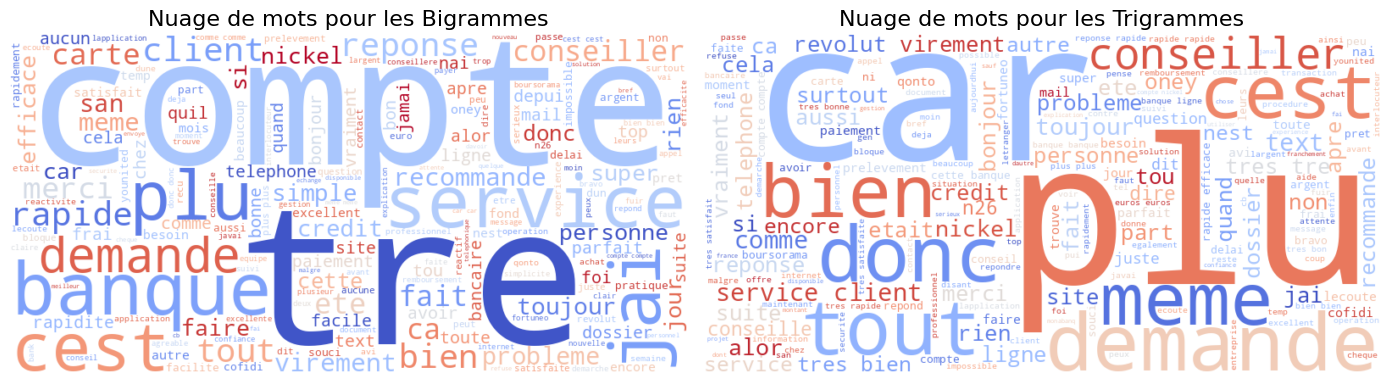

In [10]:
import pandas as pd
import string
import unicodedata
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk import FreqDist
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk

# stopwords de NLTK
nltk.download('stopwords')

# 1. Filtrer les avis extrêmes (notes 1 et 5)
df_extremes = df[df['rating'].isin([1, 5])]

# 2. Nettoyer les avis en supprimant les stopwords, la ponctuation et les accents
def clean_text(text):
    # Convertir en minuscules
    text = text.lower()
    # Supprimer les accents
    text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode('utf-8')
    # Supprimer la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Retirer les stopwords
    stop_words = set(stopwords.words('french'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Appliquer la fonction de nettoyage sur les avis
df_extremes['avis_clean'] = df_extremes['avis_global'].apply(clean_text)

# 3. Tokeniser les avis nettoyés
tokens = []
for avis in df_extremes['avis_clean']:
    tokens.extend(avis.split())

# 4. Extraire les bigrammes et trigrammes
bigrams = list(ngrams(tokens, 2))  # Bigrammes
trigrams = list(ngrams(tokens, 3))  # Trigrammes

# 5. Calculer les fréquences des bigrammes et trigrammes
bigram_freq = FreqDist(bigrams)
trigram_freq = FreqDist(trigrams)

# 6. Afficher les 10 bigrammes et trigrammes les plus fréquents
print("Top 10 des bigrammes :")
print(bigram_freq.most_common(10))
print("\nTop 10 des trigrammes :")
print(trigram_freq.most_common(10))

# 7. Générer un nuage de mots pour les bigrammes et trigrammes
# Convertir les bigrammes et trigrammes en texte pour WordCloud
bigram_text = ' '.join([' '.join(bigram) for bigram in bigram_freq.keys()])
trigram_text = ' '.join([' '.join(trigram) for trigram in trigram_freq.keys()])

# Nuages de mots
bigram_wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, colormap='coolwarm').generate(bigram_text)
trigram_wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, colormap='coolwarm').generate(trigram_text)

plt.figure(figsize=(14, 8))

# Nuage de mots pour les bigrammes
plt.subplot(1, 2, 1)
plt.imshow(bigram_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots pour les Bigrammes', fontsize=16)

# uage de mots pour les trigrammes
plt.subplot(1, 2, 2)
plt.imshow(trigram_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots pour les Trigrammes', fontsize=16)

plt.tight_layout()
plt.show()

# Annexe

On voit que le nettoyage des stops words et accents et autres on amélioré legement les resultas

In [ ]:
# Testons avec une autre méthode de vectorisation %% [markdown] TF-IDF (Term
# frequency-inverse document frequency) -Technique pour le traitement de texte
# qui reflète l'importance des mots en fonction de leurs poids dans un
# document. Bien qu'il puisse réduire considérablement la dimensionnalité des
# données textuelles, il ne tient pas compte de la signification sémantique
# des mots et peut être lent pour les grands vocabulaires. --- %%

TF-IDF (Term frequency-inverse document frequency) -Technique pour le traitement de texte qui reflète l'importance des mots en fonction de leurs poids dans un document.
Bien qu'il puisse réduire considérablement la dimensionnalité des données textuelles, il ne tient pas compte de la signification sémantique des mots et peut être lent pour les grands vocabulaires.

---



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(df['avis_clean'], df['rating_2'], test_size=0.2, random_state=42, stratify=df.rating)

tfidf = Pipeline([
    ('tfidf_clf', TfidfVectorizer()),
    ('lr', LogisticRegression())
])

tfidf.fit(X_train, y_train)

y_pred = tfidf.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

          -1       0.89      0.76      0.82      4913
           1       0.96      0.99      0.97     30638

    accuracy                           0.95     35551
   macro avg       0.93      0.87      0.90     35551
weighted avg       0.95      0.95      0.95     35551



In [ ]:
#pas d'amelioration sur le tfidf

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler,MaxAbsScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# Supposons que df soit déjà défini et contienne 'avis_global' et 'rating_2'
# Convertir les notes en format catégoriel
df['rating'] = df['rating'].map({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})

# Vérifier s'il y a des valeurs manquantes
print(df.isnull().sum())

# Supprimer les lignes avec des valeurs manquantes
df = df.dropna(subset=['avis_global', 'rating'])

# Séparer les caractéristiques et les étiquettes
X = df['avis_global']
y = df['rating']

# Convertir les données textuelles en données numériques
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X).toarray()

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardiser les données
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir les étiquettes en format catégoriel
y_train = to_categorical(y_train, num_classes=5)
y_test = to_categorical(y_test, num_classes=5)

# Construire le modèle de réseau de neurones
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(5, activation='softmax'))

# Compiler le modèle
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Entraîner le modèle
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Évaluer le modèle
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy}")

# Rapport de classification
y_pred = np.argmax(model.predict(X_test), axis=-1)
y_true = np.argmax(y_test, axis=-1)
print(classification_report(y_true, y_pred, target_names=['1', '2', '3', '4', '5']))

ID                   0
verif                0
rating               0
Date                 0
month                0
day                  0
year                 0
company              0
avis_global          0
quotes               0
hashtags             0
capslock             0
chain_capslock       0
exclamation          0
chain_exclamation    0
interogation         0
etc                  0
message_len          0
company_encoded      0
rating_2             0
dtype: int64


ValueError: empty vocabulary; perhaps the documents only contain stop words

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler,MaxAbsScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# Supposons que df soit déjà défini et contienne 'avis_global' et 'rating_2'
# Convertir les notes en format catégoriel
df['rating'] = df['rating'].map({1: -1, 2: -1, 3: 0, 4: 1, 5: 1})

# Vérifier s'il y a des valeurs manquantes
print(df.isnull().sum())

# Supprimer les lignes avec des valeurs manquantes
df = df.dropna(subset=['avis_global', 'rating'])

# Séparer les caractéristiques et les étiquettes
X = df['avis_global']
y = df['rating']

# Convertir les données textuelles en données numériques
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(X).toarray()

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardiser les données
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir les étiquettes en format catégoriel
y_train = to_categorical(y_train, num_classes=5)
y_test = to_categorical(y_test, num_classes=5)

# Construire le modèle de réseau de neurones
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(5, activation='softmax'))

# Compiler le modèle
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Entraîner le modèle
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Évaluer le modèle
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy}")

# Rapport de classification
y_pred = np.argmax(model.predict(X_test), axis=-1)
y_true = np.argmax(y_test, axis=-1)
print(classification_report(y_true, y_pred, target_names=['-1', '0', '1']))

ID                   0
verif                0
rating               0
Date                 0
month                0
day                  0
year                 0
company              0
avis_global          0
quotes               0
hashtags             0
capslock             0
chain_capslock       0
exclamation          0
chain_exclamation    0
interogation         0
etc                  0
message_len          0
company_encoded      0
rating_2             0
dtype: int64


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


NotFoundError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-packages/ipy

Matrice de confusion :
 [[ 2023  2795]
 [  644 29275]]


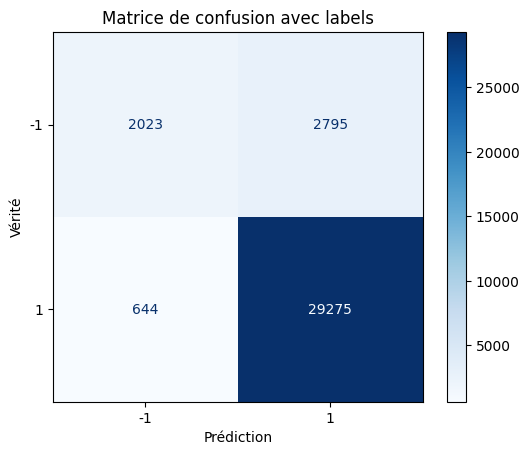

Accuracy: 0.9009989348533264
F1 Score: 0.8884913855720578


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Supposons que df est déjà défini et contient vos données
dataframe = df[['avis_clean', 'quotes', 'hashtags', 'capslock', 'chain_capslock', 'exclamation', 'chain_exclamation', 'interogation', 'message_len', 'rating_2']]
X = dataframe.drop(['avis_clean', 'rating_2'], axis=1)
y = df['rating_2']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Standardiser les données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entraîner le modèle de régression logistique
logreg = LogisticRegression(max_iter=100)
logreg.fit(X_train, y_train)

# Prédiction
y_pred = logreg.predict(X_test)

# Afficher la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :\n", cm)

# Afficher la matrice de confusion avec les noms des lignes et des colonnes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title('Matrice de confusion avec labels')
plt.xlabel('Prédiction')
plt.ylabel('Vérité')
plt.show()

# Autres métriques, si nécessaire
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')}")

In [ ]:
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
print(classification_report_imbalanced(y_test, y_pred))
#Nous voyons que le recall est mauvais pour les avis negatifs et notre modele s'est trompé régulierement sur des vrais negatifs, nous devons rééquilibrer notre jeux de données

                   pre       rec       spe        f1       geo       iba       sup

         -1       0.76      0.42      0.98      0.54      0.64      0.39      4818
          1       0.91      0.98      0.42      0.94      0.64      0.43     29919

avg / total       0.89      0.90      0.50      0.89      0.64      0.43     34737



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Matrice de confusion :
 [[ 3762  2264]
 [ 4712 25128]]


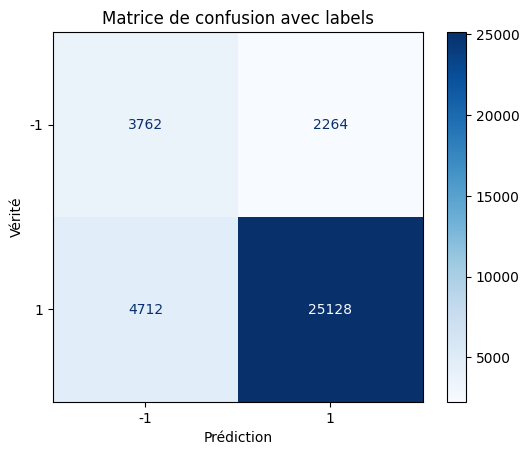

Accuracy: 0.8054982434617743
F1 Score: 0.8177571360633563


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt


# Supposons que dataframe
dataframe = df1[['avis_clean', 'quotes', 'hashtags', 'capslock', 'chain_capslock', 'exclamation', 'chain_exclamation', 'interogation', 'nb_caracter', 'rating_2']]
X = dataframe.drop(['avis_clean', 'rating_2'], axis=1)
y = df1['rating_2']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Sur-échantillonnage avec SMOTE
smote = SMOTE(random_state=1234)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardiser les données
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Entraîner le modèle RandomForestClassifier
rf = RandomForestClassifier(random_state=1234)
rf.fit(X_train_resampled, y_train_resampled)

# Prédiction
y_pred = rf.predict(X_test)

# Afficher la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :\n", cm)

# Afficher la matrice de confusion avec les noms des lignes et des colonnes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title('Matrice de confusion avec labels')
plt.xlabel('Prédiction')
plt.ylabel('Vérité')
plt.show()

# Autres métriques, si nécessaire
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')}")


In [ ]:
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
print(classification_report_imbalanced(y_test, y_pred))

                   pre       rec       spe        f1       geo       iba       sup

         -1       0.50      0.73      0.88      0.59      0.80      0.63      4818
          1       0.95      0.88      0.73      0.92      0.80      0.65     29919

avg / total       0.89      0.86      0.75      0.87      0.80      0.65     34737



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Split data in train and validate dataset.
dataframe = df1[['avis_clean','quotes', 'hashtags', 'capslock', 'chain_capslock', 'exclamation', 'chain_exclamation', 'interogation', 'nb_caracter', 'rating_2']]
X = dataframe.drop(['rating_2'], axis=1)
y = df1.rating_2
df_train, df_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
# Stopword
stopWords = set(stopwords.words('french'))
# Bag of words
vectorizer = CountVectorizer(stop_words = list(stopWords), max_features=5000)
X_train_text = vectorizer.fit_transform(df_train.avis_clean)
X_test_text = vectorizer.transform(df_test.avis_clean)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Vectorization des mots

import tensorflow as tf
# Dictionary
dictionary = {'i': 0, 'think': 1, 'therefore': 2, 'am': 3}
# One hot representation of "think"
tf.one_hot(dictionary['therefore'], 4).numpy()

array([0., 0., 1., 0.], dtype=float32)

In [ ]:
df1['etc'] = df1.avis_global.apply(lambda x: find_etc(x))

In [ ]:
#########################################################################################################################################

In [ ]:
filtered_df = df1[df1['avis_clean'].str.contains("rapide", case=False)]
display(filtered_df)

,titre,ID,verif,rating,avis,Date,month,day,year,Company Name_bforbank.com,...,Company Name_orangebank.fr,Company Name_qonto.com,Company Name_www.mafrenchbank.fr,Company Name_www.monabanq.com,Company Name_www.revolut.com,Company Name_www.younited-credit.com,avis_global,avis_clean_tokenized_PST,avis_clean,avis_tokenized
1,Application bancaire fluide,Cyril P.,Sur invitation,5,"Application bancaire fluide, rapide, ergonomiq...",2024-10-09,10,9,2024,False,...,False,False,False,False,False,False,Application bancaire fluide Application bancai...,[Application bancaire fluide Application banca...,application bancaire fluide application bancai...,"[application, bancaire, fluide, application, b..."
19,Réaction rapide de la part de la banque…,Brunet,Sur invitation,5,"Réaction rapide de la part de la banque , car ...",2024-10-08,10,8,2024,False,...,False,False,False,False,False,False,Réaction rapide de la part de la banque… Réact...,[Réaction rapide de la part de la banque… Réac...,reaction rapide part reaction rapide part car ...,"[reaction, rapide, part, reaction, rapide, par..."
22,La procédure de virement est simple,Géry PANNEQUIN,Sur invitation,5,"La procédure de virement est simple, rapide, f...",2024-10-07,10,7,2024,False,...,False,False,False,False,False,False,La procédure de virement est simple La procédu...,[La procédure de virement est simple La procéd...,procedure virement simple procedure virement s...,"[procedure, virement, simple, procedure, virem..."
28,Application super rapide et pertinente…,Maya Marza B,Sur invitation,5,Application super rapide et pertinente pour gé...,2024-10-08,10,8,2024,False,...,False,False,False,False,False,False,Application super rapide et pertinente… Applic...,[Application super rapide et pertinente… Appli...,application super rapide pertinente applicatio...,"[application, super, rapide, pertinente, appli..."
35,Super j'aime trop bourso bank,Yohan B,Sur invitation,5,Super j'aime trop bourso bank. Efficace rapide...,2024-10-06,10,6,2024,False,...,False,False,False,False,False,False,Super j'aime trop bourso bank Super j'aime tro...,[Super j'aime trop bourso bank Super j'aime tr...,super aime trop bourso bank super aime trop bo...,"[super, aime, trop, bourso, bank, super, aime,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188604,Etude très rapide et versement des…,STEPHANIE BENEJEAN,Sur invitation,5,Etude très rapide et versement des fonds très ...,2020-11-03,11,3,2020,False,...,False,False,False,False,False,False,Etude très rapide et versement des… Etude très...,[Etude très rapide et versement des… Etude trè...,etude rapide versement etude rapide versement ...,"[etude, rapide, versement, etude, rapide, vers..."
188607,Service rapide et compétent.,No Text,Sur invitation,5,No Text,2020-11-03,11,3,2020,False,...,False,False,False,False,False,False,Service rapide et compétent. No Text,"[Service rapide et compétent., No Text]",service rapide competent no,"[service, rapide, competent, no]"
188608,Service très professionnel et très…,REVEILLON OPHELIE,Sur invitation,5,Service très professionnel et très rapidement ...,2020-11-03,11,3,2020,False,...,False,False,False,False,False,False,Service très professionnel et très… Service tr...,[Service très professionnel et très… Service t...,service professionnel service professionnel ra...,"[service, professionnel, service, professionne..."
188710,Merci infiniment à cofidis,Kathy LECLERCQ,Non vérifié,5,Merci infiniment à cofidis Ce sont les seult q...,2019-08-26,8,26,2019,False,...,False,False,False,False,False,False,Merci infiniment à cofidis Merci infiniment à ...,[Merci infiniment à cofidis Merci infiniment à...,merci infiniment cofidis merci infiniment cofi...,"[merci, infiniment, cofidis, merci, infiniment..."


In [ ]:
print(avis_positifs)

0         carte piratee vacances indonesie avis utilisat...
1         application bancaire fluide application bancai...
2         peux recommander beaucoup reticents banques li...
3         connexion impossible connexion application mob...
4         satisfaite services satisfaite services pourqu...
                                ...                        
179248    part probleme societe achat amazon xpar carte ...
179274    dois deux retard paiement dois deux retard pai...
179277    infiniment infiniment seult cas besoindossier ...
179281    specialiste credit ligne meilleur specialiste ...
179323    amazon marche plutot generale poste avis conte...
Name: avis_clean, Length: 149107, dtype: object


A SUPPRIMER SI BESOIN : Visualisation du nombre d'avis par note pour chaque banque

In [ ]:
##A supprimer si besoin
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compter le nombre d'avis par note pour chaque entreprise
avis_par_note = df.groupby(['company', 'rating']).size().reset_index(name='count')

# Tracer un barplot pour visualiser le nombre d'avis par note pour chaque entreprise
plt.figure(figsize=(14, 8))
sns.barplot(x='company', y='count', hue='rating', data=avis_par_note, palette="viridis")


plt.title('Nombre d\'avis par note pour chaque entreprise', fontsize=16)
plt.xlabel('Entreprise', fontsize=14)
plt.ylabel('Nombre d\'avis', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Note', loc='upper left')


plt.tight_layout()
plt.show()

A SUPPRIMER SI BESOIN : démontrer la relation entre le nombre d'avis d'une entreprise et la proportion d'avis extrêmes (5 ou 1) par rapport aux avis intermédiaires (2, 3, 4). Le nuage de mot avec une pente négative est une bon indicateur de la tendence

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compter le nombre total d'avis et la répartition des notes par entreprise
avis_par_entreprise = df1.groupby('company')['rating'].value_counts().unstack(fill_value=0)

# 2. Calculer la proportion d'avis extrêmes (note 1 et 5) et d'avis intermédiaires (notes 2, 3, 4)
avis_par_entreprise['total'] = avis_par_entreprise.sum(axis=1)
avis_par_entreprise['avis_extremes'] = avis_par_entreprise[1] + avis_par_entreprise[5]
avis_par_entreprise['avis_intermediaires'] = avis_par_entreprise[2] + avis_par_entreprise[3] + avis_par_entreprise[4]

# Calculer les proportions
avis_par_entreprise['proportion_extremes'] = avis_par_entreprise['avis_extremes'] / avis_par_entreprise['total']
avis_par_entreprise['proportion_intermediaires'] = avis_par_entreprise['avis_intermediaires'] / avis_par_entreprise['total']

# 3. Visualiser la relation entre le nombre total d'avis et la proportion d'avis extrêmes
plt.figure(figsize=(14, 8))

# Scatter plot : Proportion d'avis extrêmes en fonction du nombre d'avis total
sns.scatterplot(x=avis_par_entreprise['total'], y=avis_par_entreprise['proportion_extremes'], hue=avis_par_entreprise.index, palette="tab20", s=100)


plt.title('Proportion d\'avis extrêmes en fonction du nombre d\'avis par entreprise', fontsize=16)
plt.xlabel('Nombre d\'avis', fontsize=14)
plt.ylabel('Proportion d\'avis extrêmes (note 1 ou 5)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Entreprise', loc='upper left')


plt.tight_layout()
plt.show()

A SUPPRIMER SI BESOIN : vizualisation des nuages de mots pour les deux notes extremes, dans deux nuages séparés

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import unicodedata
from nltk.corpus import stopwords


# 1. Filtrer les avis extrêmes (notes 1 et 5)
df_extremes_1 = df[df['rating'] == 1]
df_extremes_5 = df[df['rating'] == 5]

# 2. Nettoyer les avis en supprimant les stopwords, la ponctuation et les accents
def clean_text(text):
    # Minusculisation
    text = text.lower()
    # Elever les accents
    text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode('utf-8')
    # Supprimer la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Retirer les stopwords
    stop_words = set(stopwords.words('french'))  # NLK
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Appliquer la fonction de nettoyage sur les avis
df_extremes_1['avis_clean'] = df_extremes_1['avis-clean'].apply(clean_text)
df_extremes_5['avis_clean'] = df_extremes_5['avis-clean'].apply(clean_text)

# 3. Vectorisation avec TfidfVectorizer pour les deux groupes (note 1 et 5)
vectorizer = TfidfVectorizer(max_features=1000, stop_words='french')

# Vectorisation pour les avis avec note 1
X_1 = vectorizer.fit_transform(df_extremes_1['avis_clean'])

# Vectorisation pour les avis avec note 5
X_5 = vectorizer.fit_transform(df_extremes_5['avis_clean'])

# 4. Créer les nuages de mots
wordcloud_1 = WordCloud(width=800, height=400, background_color='white', max_words=200, colormap='coolwarm').generate_from_frequencies(dict(zip(vectorizer.get_feature_names_out(), X_1.sum(axis=0).A1)))
wordcloud_5 = WordCloud(width=800, height=400, background_color='white', max_words=200, colormap='coolwarm').generate_from_frequencies(dict(zip(vectorizer.get_feature_names_out(), X_5.sum(axis=0).A1)))

# 5. Afficher les nuages de mots
plt.figure(figsize=(14, 8))

# Nuage de mots pour la note 1
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_1, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots pour les avis avec la note 1', fontsize=16)

# Nuage de mots pour la note 5
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_5, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots pour les avis avec la note 5', fontsize=16)


plt.tight_layout()
plt.show()

ASUPPRIMER SI BESOIN : On commence par filtrer les avis qui ont une note 1 ou 5 dans la colonne ratin,
La fonction clean_text est utilisée pour nettoyer les avis. Cela inclut la conversion en minuscules, la suppression des accents, de la ponctuation et des stopwords (mots fréquents qui ne portent pas beaucoup de sens, comme "le", "et", "de", etc.).Après avoir nettoyé le texte, les avis sont divisés en tokens. Les tokens sont ensuite utilisés pour extraire les bigrammes et trigrammes
Avec la fonction ngrams de NLTK, nous extrayons des paires de mots (bigrammes) et des triplets de mots (trigrammes) à partir des tokens
FreqDist est utilisé pour compter combien de fois chaque bigramme ou trigramme apparaît dans l'ensemble des avis.